# DFCViT-4C++ : Shortcut-Aware Lightweight Hybrid CNN–Transformer for 4-Class Dragon Fruit Grading
**Target:** Q1 journal submission · **Hardware:** NVIDIA DGX Spark (GB10 Grace-Blackwell, 128 GB unified memory, ARM64)

### Novel contributions implemented in this notebook
| # | Contribution | What it does | Inference cost |
|---|---|---|---|
| C1 | **DFCViT-4C** hybrid | MobileNetV2 features → CBAM → 2-layer Transformer on 7×7 tokens (≈3.0 M params) | – |
| C2 | **MGAS** – Mask-Guided Attention Supervision | CBAM spatial-attention map is supervised with the fruit mask (BCE), so the model is *told* where the fruit is during training | **zero** (training only) |
| C3 | **CCBS** – Cross-Class Background Swap | Fruit is pasted onto a background taken from a *different class*, breaking the background ↔ label correlation | **zero** (training only) |
| C4 | **Shortcut-audit protocol** | Foreground-only / Background-only test views + Shortcut Reliance Index (SRI) + Grad-CAM Energy-in-Fruit Ratio (EFR) | evaluation only |

### Fixes vs. the previous notebook (reviewer-proof protocol)
| Previous problem | Fix here |
|---|---|
| Background shortcut (white bg = Defect/Bad, field = Immature/Mature) | C2 + C3 + C4, audited for every model |
| Baselines / ablation / k-fold picked best epoch **on the test set** | Every run selects on **validation** only; test touched once |
| Unequal training recipe for baselines | One shared engine: same aug, sampler, loss, schedule, early stopping, LR-grid on val |
| Wrong McNemar (built from accuracy totals) | Exact paired McNemar on per-image predictions + Holm correction |
| Path-only leakage check | MD5 exact + pHash near-duplicate grouping → **group-aware** stratified split |
| Fake "Optuna" (hard-coded trials) | Real Optuna TPE search (SQLite, resumable, pruning) on validation |
| Warm-up LR = 0 in epoch 1, `cudnn.benchmark=True` breaking determinism | Fixed warm-up `(ep+1)/W`; deterministic cuDNN |
| Class weights from full data + sampler + focal (triple correction) | Sampler + focal only, computed on train split |
| Strong hue jitter (colour = maturity cue) | Hue jitter limited to ±0.02 |
| Grad-CAM on 1-channel CBAM conv, training images | Grad-CAM on 256-ch projection, **test** images, misclassified included, `strict=True` loading |
| Single seed | 3 seeds, mean ± std everywhere |
| GPU idle – CPU `DataLoader` workers hung | **GPU-resident pipeline**: all images on the GPU, augmentation as batched GPU ops, no worker processes; fused AdamW, bf16, channels-last |

### Checkpointing (safe to stop & re-run any time)
* Every stage writes a cache (`dragon_q1_outputs/cache`). Re-running skips finished stages.
* Every training run writes `last.pt` **every epoch** (resume after crash) + `best.pt` + `result.json` (run is skipped when present).
* Optuna uses an SQLite study → continues where it stopped.
* Final model: `dragon_q1_outputs/models/DFCViT4C_MGAS_CCBS_final.pt` (+ TorchScript `.pt`).

## 0 · Setup — everything happens inside VS Code (no separate script)
1. **VS Code → Extensions (Ctrl+Shift+X)** → install **Python** and **Jupyter** (both by Microsoft).
2. **File → Open Folder…** → `/home/aiub/Dragon` (put this notebook there).
3. **Ctrl+Shift+P → "Python: Create Environment" → Venv → Python 3.x** → VS Code creates `/home/aiub/Dragon/.venv`.
   *(Only if VS Code says the venv module is missing, run once in a terminal: `sudo apt install python3-venv`.)*
4. Open this notebook → **Select Kernel** (top-right) → **Python Environments → .venv**.
   VS Code asks to install **ipykernel** → click **Install**. This `.venv` is the kernel for the whole project.
5. **Run All.** Cell 1 installs only the packages this notebook needs, into the `.venv` (PyTorch with the correct CUDA build is chosen
   automatically from `nvidia-smi`). Nothing is installed system-wide.

**Packages installed by Cell 1 (nothing else):** `torch`, `torchvision`, `timm`, `optuna`, `scikit-learn`, `scipy`, `pandas`, `matplotlib`,
`seaborn`, `opencv-python-headless`, `pillow`, `tqdm`, `onnxruntime` (+ their own required dependencies).

* Dataset path (Cell 3): `/home/aiub/Dragon/archive/Dragon Fruit` → must contain `Bad`, `Defect`, `Immature`, `Mature`.
* Outputs: `/home/aiub/Dragon/dragon_q1_outputs`. If anything stops, run again — finished work is reloaded from checkpoints.
* The first run needs internet: ImageNet weights (Hugging Face) and the U²-Net mask model (176 MB, GitHub) are downloaded once.
> ℹ️ On DGX Spark a warning like *"GB10 … cuda capability 12.1 … maximum supported (12.0)"* is harmless (sm_120 ↔ sm_121 binary-compatible).

## 1 · Install / verify Python packages

In [1]:
# ── 1 · Install ONLY the required packages into this kernel's environment ─────
import sys, subprocess, importlib, importlib.util, platform, re, shutil

print(f"Python      : {sys.version.split()[0]}  ({platform.machine()})")
print(f"Interpreter : {sys.executable}")
if sys.prefix == sys.base_prefix:
    raise SystemExit("This kernel is the SYSTEM Python (Ubuntu blocks pip there).\n"
                     "In VS Code: Ctrl+Shift+P → 'Python: Create Environment' → Venv, then Select Kernel → .venv, "
                     "and run this cell again.")

def pip_install(*args):
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-1500:]); print(r.stderr[-3000:])
        raise RuntimeError("pip install failed – see the log above")

# 1) PyTorch + torchvision with the CUDA build that matches the NVIDIA driver
def torch_has_cuda():
    if importlib.util.find_spec("torch") is None:
        return False
    r = subprocess.run([sys.executable, "-c", "import torch; print(torch.cuda.is_available())"],
                       capture_output=True, text=True)
    return r.stdout.strip() == "True"

if not torch_has_cuda():
    cuda_major = 0
    if shutil.which("nvidia-smi"):
        m = re.search(r"CUDA Version:\s*(\d+)", subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
        cuda_major = int(m.group(1)) if m else 0
    if cuda_major == 0:
        raise SystemExit("nvidia-smi not found / no NVIDIA driver – install the GPU driver first.")
    index = "https://download.pytorch.org/whl/cu130" if cuda_major >= 13 else "https://download.pytorch.org/whl/cu128"
    print(f"Driver supports CUDA {cuda_major}.x → installing torch + torchvision from {index} (takes a few minutes) …")
    pip_install("--force-reinstall", "torch", "torchvision", "--index-url", index)

# 2) Remaining packages (only what this notebook imports)
REQUIRED = [  # (import name, pip requirement)
    ("timm", "timm>=1.0.9"), ("optuna", "optuna>=4.0"), ("sklearn", "scikit-learn>=1.4"),
    ("scipy", "scipy>=1.11"), ("pandas", "pandas>=2.1"), ("matplotlib", "matplotlib>=3.8"),
    ("seaborn", "seaborn>=0.13"), ("cv2", "opencv-python-headless>=4.9"), ("PIL", "pillow>=10.0"),
    ("tqdm", "tqdm>=4.66"), ("onnxruntime", "onnxruntime>=1.17"),
]
missing = [spec for mod, spec in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", " ".join(missing)); pip_install(*missing)
importlib.invalidate_caches()

_chk = subprocess.run([sys.executable, "-c",
    "import torch, torchvision; print(torch.__version__, torchvision.__version__, torch.cuda.is_available(), "
    "torch.cuda.get_device_name(0) if torch.cuda.is_available() else '-')"], capture_output=True, text=True)
print("\ntorch | torchvision | CUDA available | GPU :", _chk.stdout.strip() or _chk.stderr.strip()[-600:])
print("Packages:")
for mod, spec in [("torch", "torch"), ("torchvision", "torchvision")] + REQUIRED:
    print(f"  {'✓' if importlib.util.find_spec(mod) is not None else '✗'} {spec}")
print("\nSetup complete ✓  (no kernel restart needed)")

Python      : 3.14.6  (aarch64)
Interpreter : /home/aiub/.venv/bin/python

torch | torchvision | CUDA available | GPU : 2.14.0+cu130 0.29.0+cu130 True NVIDIA GB10
Packages:
  ✓ torch
  ✓ torchvision
  ✓ timm>=1.0.9
  ✓ optuna>=4.0
  ✓ scikit-learn>=1.4
  ✓ scipy>=1.11
  ✓ pandas>=2.1
  ✓ matplotlib>=3.8
  ✓ seaborn>=0.13
  ✓ opencv-python-headless>=4.9
  ✓ pillow>=10.0
  ✓ tqdm>=4.66
  ✓ onnxruntime>=1.17

Setup complete ✓  (no kernel restart needed)


## 2 · Imports, GPU check, reproducibility, plotting helpers

In [2]:
# ── 2 · Imports & environment ─────────────────────────────────────────────────
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # required for deterministic cuBLAS
os.environ.setdefault("PYTHONHASHSEED", "0")

import gc, json, math, time, copy, random, shutil, hashlib, warnings, platform
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision import tv_tensors
import timm
import optuna

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from scipy import stats

warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")
warnings.filterwarnings("ignore", message=".*cuda capability.*")
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 70)
print(f"PyTorch {torch.__version__} | torchvision {__import__('torchvision').__version__} | timm {timm.__version__}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | OpenCV {cv2.__version__} | Optuna {optuna.__version__}")
if DEVICE.type == "cuda":
    _p = torch.cuda.get_device_properties(0)
    print(f"GPU     : {_p.name}  (compute capability {_p.major}.{_p.minor})")
    print(f"Memory  : {_p.total_memory / 1e9:.1f} GB visible to CUDA (unified memory on DGX Spark)")
    AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
else:
    if os.environ.get("DRAGON_ALLOW_CPU") != "1":
        raise RuntimeError(
            "PyTorch cannot see the GPU, so training would silently run on the CPU.\n"
            f"  torch {torch.__version__} | built for CUDA {torch.version.cuda}\n"
            "Fix: run Cell 1 again (it reinstalls the CUDA build of PyTorch), then Kernel → Restart, then run from Cell 1.\n"
            "Also check `nvidia-smi` works in a terminal.")
    print("⚠ DRAGON_ALLOW_CPU=1 → running on CPU (testing only).")
    AMP_DTYPE = torch.bfloat16
print(f"Device  : {DEVICE} | mixed precision dtype: {AMP_DTYPE}")
if DEVICE.type == "cuda":                                   # quick proof that the GPU really computes
    _a = torch.randn(4096, 4096, device=DEVICE, dtype=torch.bfloat16); torch.cuda.synchronize(); _t = time.time()
    for _ in range(20): _b = _a @ _a
    torch.cuda.synchronize(); _tf = 20 * 2 * 4096 ** 3 / (time.time() - _t) / 1e12
    print(f"GPU check: bf16 matmul ≈ {_tf:.1f} TFLOP/s ✓  (computation is running on {torch.cuda.get_device_name(0)})")
    del _a, _b; torch.cuda.empty_cache()
print(f"CPU     : {os.cpu_count()} logical cores | arch {platform.machine()}")
print("=" * 70)

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.backends.cudnn.benchmark = False          # FIX: benchmark=True broke determinism before
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cuda.matmul.allow_tf32 = True    # TF32 is deterministic and fast on Blackwell
torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def autocast_ctx():
    return torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE)

set_seed(42)

# ── Plot style (Q1 figures: 300-dpi PNG + vector PDF) ─────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 10,
                     "axes.titleweight": "bold", "axes.titlesize": 11})
CLASS_COLORS = ["#C0392B", "#E67E22", "#27AE60", "#8E44AD"]   # Bad, Defect, Immature, Mature
print("Imports, device and reproducibility settings ready ✓")

/home/aiub/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.14.0+cu130 | torchvision 0.29.0+cu130 | timm 1.0.30
NumPy 2.5.2 | pandas 3.0.6 | OpenCV 5.0.0 | Optuna 5.0.0
GPU     : NVIDIA GB10  (compute capability 12.1)
Memory  : 130.7 GB visible to CUDA (unified memory on DGX Spark)
Device  : cuda | mixed precision dtype: torch.bfloat16
GPU check: bf16 matmul ≈ 11.0 TFLOP/s ✓  (computation is running on NVIDIA GB10)
CPU     : 20 logical cores | arch aarch64
Imports, device and reproducibility settings ready ✓


## 3 · Configuration, output folders, checkpoint helpers
Edit **only this cell** if you need to change paths or budgets. `RUN_*` switches let you skip heavy stages.

In [3]:
# ── 3 · Configuration ─────────────────────────────────────────────────────────
class CFG:
    # Paths
    DATA_ROOT   = Path("/home/aiub/Dragon/archive/Dragon Fruit")          # folder with Bad/Defect/Immature/Mature
    WORK_DIR    = Path("/home/aiub/Dragon/dragon_q1_outputs")              # all outputs / checkpoints / models

    # Data
    CLASSES      = ["Bad", "Defect", "Immature", "Mature"]
    NUM_CLASSES  = 4
    CACHE_SIZE   = 256          # images are decoded once and cached at 256×256
    IMG_SIZE     = 224
    TEST_FRAC    = 0.20
    VAL_FRAC     = 0.10
    UNDERSAMPLE_TRAIN_TO = None # e.g. 1000 → cap majority classes in TRAIN only; None = use all images
    PHASH_HAMMING = 4           # ≤4/64 bits different → near-duplicate (same group)
    DROP_CROSS_CLASS_DUPLICATES = True

    # Foreground masks
    MASK_MODEL_URL = "https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx"  # U²-Net (salient object) ONNX
    MASK_MIN_AREA = 0.02
    MASK_MAX_AREA = 0.92

    # Model
    BACKBONE   = "mobilenetv2_100"
    EMBED_DIM  = 256
    NUM_HEADS  = 8
    DEPTH      = 2
    PRETRAINED = True

    # Training (shared by EVERY model → fair comparison)
    SEEDS            = [42, 123, 2024]
    BATCH_SIZE       = 64       # training batch (whole pipeline runs on the GPU)
    EVAL_BATCH_SIZE  = 256      # validation / test batch
    EPOCHS           = 60
    WARMUP_EPOCHS    = 5
    PATIENCE         = 12       # early stopping on validation NLL
    BACKBONE_LR_MULT = 0.1      # pretrained part learns 10× slower (all models)
    GRAD_CLIP        = 1.0
    FOCAL_GAMMA      = 2.0
    LABEL_SMOOTHING  = 0.10
    MIXUP_P          = 0.5      # probability a batch is mixed (alpha tuned by Optuna)

    # Default hyper-parameters (overwritten by Optuna result)
    DEFAULT_HP = dict(lr=3e-4, weight_decay=5e-4, dropout=0.30, drop_path=0.10,
                      mixup_alpha=0.2, mgas_lambda=0.5, bgswap_p=0.5)

    # Optuna
    RUN_OPTUNA     = True
    OPTUNA_TRIALS  = 40         # upper limit
    OPTUNA_MIN_TRIALS = 25      # never stop before this many finished trials
    OPTUNA_PATIENCE   = 15      # stop when the best trial is this many trials old
    OPTUNA_EPOCHS  = 20

    # Baselines (same literature backbones as before)
    RUN_BASELINES = True
    BASELINES = {"ResNet-50": "resnet50", "EfficientNet-B0": "efficientnet_b0",
                 "ConvNeXt-Tiny": "convnext_tiny", "DeiT-Tiny": "deit_tiny_patch16_224",
                 "DenseNet201": "densenet201", "VGG16": "vgg16"}
    BASELINE_LR_GRID  = [1e-4, 3e-4]
    BGSWAP_BASELINES  = ["ResNet-50", "EfficientNet-B0", "DeiT-Tiny"]  # fairness check: do they gain from CCBS too?

    RUN_ABLATION = True
    RUN_KFOLD    = True
    KFOLDS       = 5
    RUN_XAI      = True
    N_BOOT       = 2000

C = CFG
K = C.NUM_CLASSES
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
GRAY_BG = np.array([124, 116, 104], dtype=np.float32)    # ImageNet mean colour (neutral background)

CACHE_DIR = C.WORK_DIR / "cache"
CKPT_DIR  = C.WORK_DIR / "checkpoints"
MODEL_DIR = C.WORK_DIR / "models"
FIG_DIR   = C.WORK_DIR / "figures"
TAB_DIR   = C.WORK_DIR / "tables"
for _d in (CACHE_DIR, CKPT_DIR, MODEL_DIR, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# ── JSON / checkpoint helpers ─────────────────────────────────────────────────
def _to_py(o):
    if isinstance(o, dict):  return {str(k): _to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_to_py(v) for v in o]
    if isinstance(o, np.ndarray): return o.tolist()
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    if isinstance(o, Path): return str(o)
    return o

def save_json(obj, path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w") as f: json.dump(_to_py(obj), f)
    os.replace(tmp, path)

def load_json(path):
    with open(path) as f: return json.load(f)

def atomic_torch_save(obj, path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp); os.replace(tmp, path)

def save_fig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  ↳ figure saved: figures/{name}.png (+ .pdf)")

def save_table(df, name, caption=""):
    df.to_csv(TAB_DIR / f"{name}.csv", index=False)
    print(f"  ↳ table saved: tables/{name}.csv")

def fmt_ms(values, d=4):
    v = np.asarray(values, dtype=float)
    return f"{v.mean():.{d}f} ± {v.std(ddof=1) if len(v) > 1 else 0.0:.{d}f}"

print("Configuration")
print("-" * 70)
for k, v in vars(CFG).items():
    if not k.startswith("_"):
        print(f"  {k:<28}: {v}")
print("-" * 70)
print(f"Outputs → {C.WORK_DIR.resolve()}")

def checkpoint_report():
    """Show which stages / runs are already finished (they are skipped on re-run)."""
    stages = [("verified file list", CACHE_DIR / "meta_verified.csv"), ("image cache 256px", CACHE_DIR / "images_256.npy"),
              ("fruit masks", CACHE_DIR / "masks_256.json"), ("FG-only views", CACHE_DIR / "fg_only_256.npy"),
              ("BG-only views", CACHE_DIR / "bg_only_256.npy"), ("train/val/test split", CACHE_DIR / "split.json"),
              ("Optuna study (SQLite)", CKPT_DIR / "optuna.db"), ("best hyper-parameters", CKPT_DIR / "best_hp.json"),
              ("final model .pt", MODEL_DIR / "DFCViT4C_MGAS_CCBS_final.pt")]
    print("\nCHECKPOINT STATUS")
    for name, p in stages:
        extra = ""
        if p.name == "masks_256.json" and p.exists():
            extra = f"  ({load_json(p).get('done', 0)} images done)"
        print(f"  {'✓' if p.exists() else '·'} {name:<24} {p.relative_to(C.WORK_DIR)}{extra}")
    done = sorted(p.parent.relative_to(CKPT_DIR) for p in CKPT_DIR.rglob("result.json"))
    part = sorted(p.parent.relative_to(CKPT_DIR) for p in CKPT_DIR.rglob("last.pt"))
    print(f"  ✓ finished training runs : {len(done)}")
    print(f"  ↻ runs that will RESUME  : {len(part)} {[str(p) for p in part][:6]}")

checkpoint_report()

Configuration
----------------------------------------------------------------------
  DATA_ROOT                   : /home/aiub/Dragon/archive/Dragon Fruit
  WORK_DIR                    : /home/aiub/Dragon/dragon_q1_outputs
  CLASSES                     : ['Bad', 'Defect', 'Immature', 'Mature']
  NUM_CLASSES                 : 4
  CACHE_SIZE                  : 256
  IMG_SIZE                    : 224
  TEST_FRAC                   : 0.2
  VAL_FRAC                    : 0.1
  UNDERSAMPLE_TRAIN_TO        : None
  PHASH_HAMMING               : 4
  DROP_CROSS_CLASS_DUPLICATES : True
  MASK_MODEL_URL              : https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx
  MASK_MIN_AREA               : 0.02
  MASK_MAX_AREA               : 0.92
  BACKBONE                    : mobilenetv2_100
  EMBED_DIM                   : 256
  NUM_HEADS                   : 8
  DEPTH                       : 2
  PRETRAINED                  : True
  SEEDS                       : [42, 123, 2024]
  

## 4 · Locate dataset, verify every image, remove exact duplicates, class statistics
**Provenance (write this in the paper):** Immature (1,241) and Defect (754) match Khatun et al., *Data in Brief* 2024 exactly;
**Mature (1,784) = Khatun "Mature" (887) + "Fresh" (898)**; **Bad (307)** comes from the Kaggle 4-class release. The classes therefore come
from different capture settings — the reason we audit background shortcuts below.

Dataset root: /home/aiub/Dragon/archive/Dragon Fruit
✓ Loaded verified file list from checkpoint (4086 files)

Files found            : 4086
Corrupt / unreadable   : 0
Exact dup. (same class): 739 removed
Exact dup. (cross-cls) : 6 removed (ambiguous labels)
Images kept            : 3341



,images,share %,imbalance (max/cls)
cls,,,
Bad,297,8.9,5.34
Defect,749,22.4,2.12
Immature,708,21.2,2.24
Mature,1587,47.5,1.00


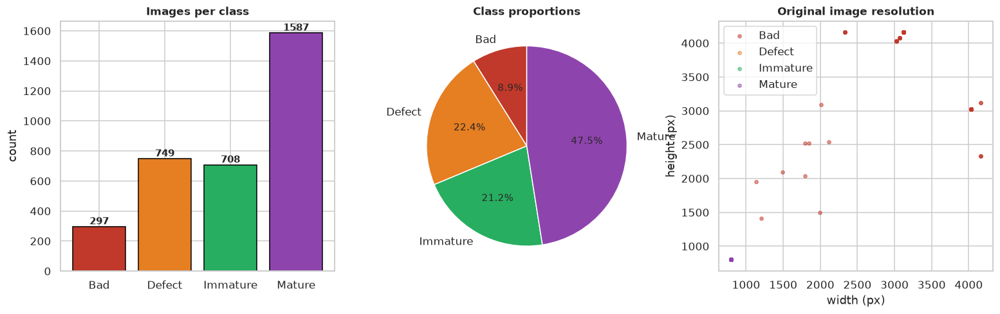

  ↳ figure saved: figures/fig01_class_distribution.png (+ .pdf)


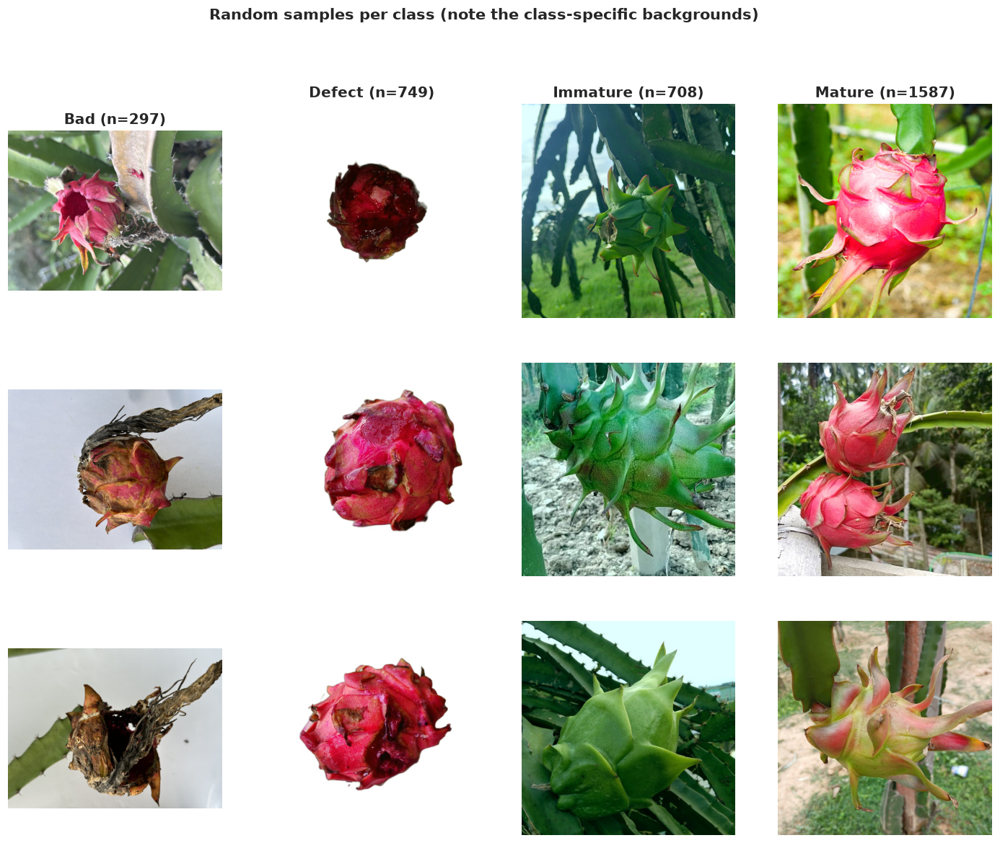

  ↳ figure saved: figures/fig02_samples_per_class.png (+ .pdf)


In [4]:
# ── 4 · Dataset discovery & verification ─────────────────────────────────────
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_dataset_root(base):
    base = Path(base)
    if not base.exists():
        return None
    want = {c.lower() for c in C.CLASSES}
    for root, dirs, _ in os.walk(base):
        if want.issubset({d.lower() for d in dirs}):
            return Path(root)
    return None

def class_dir(root, cls):
    for d in sorted(Path(root).iterdir()):
        if d.is_dir() and d.name.lower() == cls.lower():
            return d
    raise FileNotFoundError(f"class folder '{cls}' not found in {root}")

DATA_DIR = find_dataset_root(C.DATA_ROOT)
if DATA_DIR is None:
    raise FileNotFoundError(
        f"Could not find a folder containing {C.CLASSES}.\n"
        f"Check that {C.DATA_ROOT} exists and contains the folders Bad, Defect, Immature, Mature "
        "(run  ls \"/home/aiub/Dragon/archive/Dragon Fruit\"  in a terminal), or fix CFG.DATA_ROOT in Cell 3.")
print(f"Dataset root: {DATA_DIR}")

META_RAW_PATH = CACHE_DIR / "meta_verified.csv"
_all_files = []
for ci, cls in enumerate(C.CLASSES):
    files = sorted(p for p in class_dir(DATA_DIR, cls).rglob("*")
                   if p.is_file() and p.suffix.lower() in IMG_EXT)
    _all_files += [(str(p), ci, cls) for p in files]
_sig_files = hashlib.md5("|".join(f for f, _, _ in _all_files).encode()).hexdigest()

if META_RAW_PATH.exists() and load_json(CACHE_DIR / "meta_verified.json").get("sig") == _sig_files:
    META_RAW = pd.read_csv(META_RAW_PATH)
    print(f"✓ Loaded verified file list from checkpoint ({len(META_RAW)} files)")
else:
    def _verify(path):
        try:
            with Image.open(path) as im:
                w, h = im.size
                im.verify()
            md5 = hashlib.md5(Path(path).read_bytes()).hexdigest()
            return True, w, h, md5
        except Exception:
            return False, 0, 0, ""
    with ThreadPoolExecutor(max_workers=16) as ex:
        _res = list(tqdm(ex.map(_verify, [f for f, _, _ in _all_files]),
                         total=len(_all_files), desc="Verifying images"))
    META_RAW = pd.DataFrame(
        [dict(path=f, label=ci, cls=cls, ok=ok, width=w, height=h, md5=m)
         for (f, ci, cls), (ok, w, h, m) in zip(_all_files, _res)])
    META_RAW.to_csv(META_RAW_PATH, index=False)
    save_json({"sig": _sig_files}, CACHE_DIR / "meta_verified.json")

n_corrupt = int((~META_RAW.ok).sum())
META = META_RAW[META_RAW.ok].copy()

# Exact duplicates (identical bytes)
_dup_groups = META.groupby("md5")
_cross_md5 = [m for m, g in _dup_groups if g.label.nunique() > 1]
_within_md5 = [m for m, g in _dup_groups if len(g) > 1 and g.label.nunique() == 1]
n_within = int(sum(len(_dup_groups.get_group(m)) - 1 for m in _within_md5))
n_cross = int(sum(len(_dup_groups.get_group(m)) for m in _cross_md5))
META = META[~META.md5.isin(_cross_md5)]                       # ambiguous label → drop all copies
META = META.drop_duplicates(subset="md5", keep="first")        # same label → keep one
META = META.reset_index(drop=True)

print(f"\nFiles found            : {len(META_RAW)}")
print(f"Corrupt / unreadable   : {n_corrupt}")
print(f"Exact dup. (same class): {n_within} removed")
print(f"Exact dup. (cross-cls) : {n_cross} removed (ambiguous labels)")
print(f"Images kept            : {len(META)}\n")
_cnt = META.cls.value_counts().reindex(C.CLASSES)
display(pd.DataFrame({"images": _cnt, "share %": (100 * _cnt / _cnt.sum()).round(1),
                      "imbalance (max/cls)": (_cnt.max() / _cnt).round(2)}))

# Figure 1: class distribution + original resolutions
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].bar(C.CLASSES, _cnt.values, color=CLASS_COLORS, edgecolor="black")
for i, v in enumerate(_cnt.values):
    ax[0].text(i, v + 15, str(v), ha="center", fontweight="bold")
ax[0].set_title("Images per class"); ax[0].set_ylabel("count")
ax[1].pie(_cnt.values, labels=C.CLASSES, colors=CLASS_COLORS, autopct="%1.1f%%", startangle=90,
          wedgeprops=dict(edgecolor="white"))
ax[1].set_title("Class proportions")
for ci, cls in enumerate(C.CLASSES):
    s = META[META.label == ci]
    ax[2].scatter(s.width, s.height, s=12, alpha=0.5, color=CLASS_COLORS[ci], label=cls)
ax[2].set_xlabel("width (px)"); ax[2].set_ylabel("height (px)"); ax[2].legend()
ax[2].set_title("Original image resolution")
save_fig(fig, "fig01_class_distribution")

# Figure 2: sample grid (3 per class)
_rng = np.random.default_rng(42)
fig, axes = plt.subplots(3, K, figsize=(4 * K, 12))
for ci, cls in enumerate(C.CLASSES):
    paths = META[META.label == ci].path.values
    for r, p in enumerate(_rng.choice(paths, 3, replace=False)):
        axes[r, ci].imshow(Image.open(p).convert("RGB")); axes[r, ci].axis("off")
        if r == 0: axes[r, ci].set_title(f"{cls} (n={_cnt[cls]})", fontsize=13)
fig.suptitle("Random samples per class (note the class-specific backgrounds)", fontsize=14, fontweight="bold")
save_fig(fig, "fig02_samples_per_class")

## 5 · Decode & cache all images at 256×256 (checkpointed)
Decoding 800×800 JPEGs every epoch is the main CPU bottleneck. We decode once into a NumPy cache (~0.8 GB RAM).

✓ Loaded cache 'images_256' from checkpoint
Image cache: (3341, 256, 256, 3)  0.66 GB  dtype=uint8


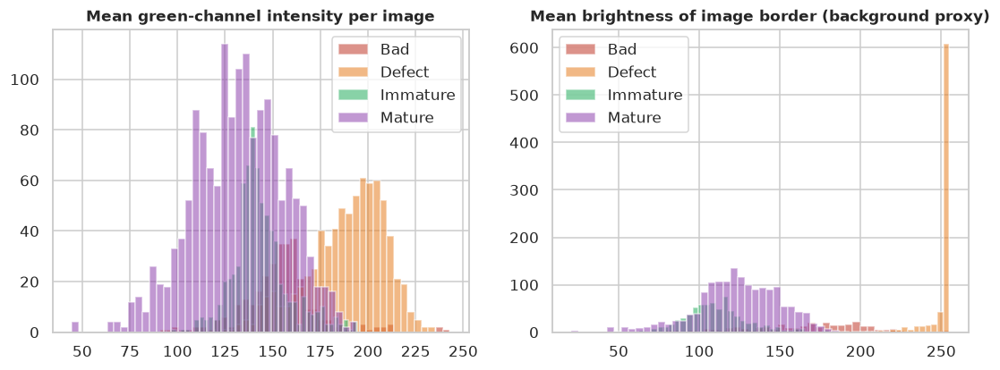

  ↳ figure saved: figures/fig03_colour_and_background_statistics.png (+ .pdf)
A strongly class-separated border-brightness histogram = evidence of a background shortcut.


In [5]:
# ── 5 · Image cache ───────────────────────────────────────────────────────────
S = C.CACHE_SIZE

def load_resize(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        img = np.array(Image.open(path).convert("RGB"))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (S, S), interpolation=cv2.INTER_AREA)

def cached_array(name, paths, builder, shape, dtype=np.uint8, workers=16, desc="", key_extra=""):
    """Build (or reload) an N×… array cache keyed by the exact image list."""
    arr_path, sig_path = CACHE_DIR / f"{name}.npy", CACHE_DIR / f"{name}.json"
    sig = hashlib.md5(("|".join(paths) + str(shape) + str(key_extra)).encode()).hexdigest()
    if arr_path.exists() and sig_path.exists() and load_json(sig_path).get("sig") == sig:
        print(f"✓ Loaded cache '{name}' from checkpoint")
        return np.load(arr_path)
    mm = np.lib.format.open_memmap(arr_path, mode="w+", dtype=dtype, shape=(len(paths),) + tuple(shape))
    def _work(i):
        mm[i] = builder(i)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        list(tqdm(ex.map(_work, range(len(paths))), total=len(paths), desc=desc or name))
    mm.flush(); del mm
    save_json({"sig": sig}, sig_path)
    return np.load(arr_path)

_paths = META.path.tolist()
IMGS_ALL = cached_array(f"images_{S}", _paths, lambda i: load_resize(_paths[i]), (S, S, 3), desc="Decoding")
print(f"Image cache: {IMGS_ALL.shape}  {IMGS_ALL.nbytes / 1e9:.2f} GB  dtype={IMGS_ALL.dtype}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for ci, cls in enumerate(C.CLASSES):
    sub = IMGS_ALL[(META.label == ci).values]
    ax[0].hist(sub.reshape(len(sub), -1, 3).mean(1)[:, 1], bins=40, alpha=0.55,
               color=CLASS_COLORS[ci], label=cls)
    border = np.concatenate([sub[:, :12].reshape(len(sub), -1, 3), sub[:, -12:].reshape(len(sub), -1, 3)], 1)
    ax[1].hist(border.mean((1, 2)), bins=40, alpha=0.55, color=CLASS_COLORS[ci], label=cls)
ax[0].set_title("Mean green-channel intensity per image"); ax[0].legend()
ax[1].set_title("Mean brightness of image border (background proxy)"); ax[1].legend()
save_fig(fig, "fig03_colour_and_background_statistics")
print("A strongly class-separated border-brightness histogram = evidence of a background shortcut.")

## 6 · Near-duplicate detection (perceptual hash) → duplicate **groups**
The previous leakage check only compared file paths. Here, images whose 64-bit pHash differs in ≤ `PHASH_HAMMING` bits are
linked (union-find) into one group. The split in Cell 9 keeps every group inside a single split, so near-identical shots
of the same fruit can never appear in both train and test.

pHash: 100%|██████████| 3341/3341 [00:00<00:00, 26479.61it/s]

Near-duplicate pairs (≤4 bits) : 1273
Groups with >1 image              : 718
Largest group size                : 8
Cross-class near-duplicate groups : 0 → 0 images dropped (label conflict)


Working set: 3341 images | 2418 independent groups


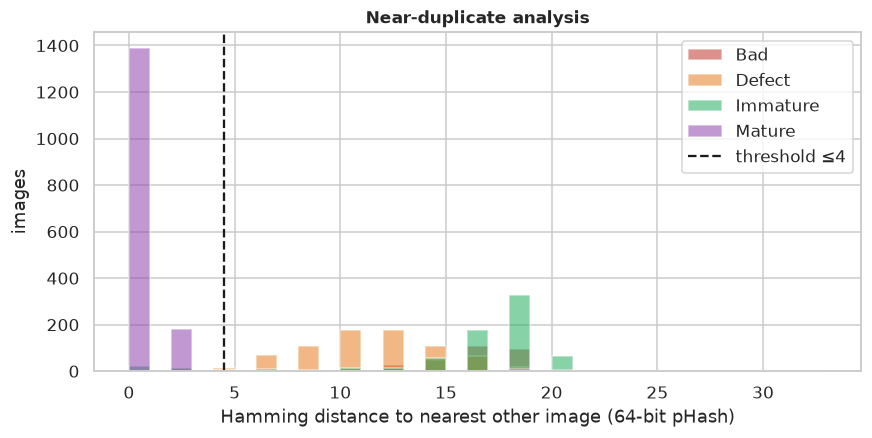

  ↳ figure saved: figures/fig04_phash_nearest_neighbour.png (+ .pdf)


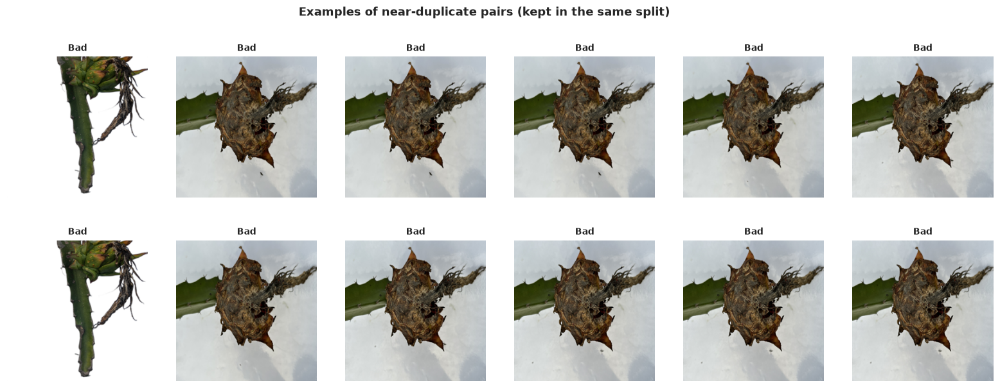

  ↳ figure saved: figures/fig05_near_duplicate_examples.png (+ .pdf)


In [6]:
# ── 6 · pHash near-duplicate grouping ─────────────────────────────────────────
def phash64(img_rgb):
    g = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    g = cv2.resize(g, (32, 32), interpolation=cv2.INTER_AREA).astype(np.float32)
    d = cv2.dct(g)[:8, :8].flatten()
    bits = d > np.median(d[1:])
    return np.packbits(bits).view(np.uint64)[0]

def popcount64(x):
    if hasattr(np, "bitwise_count"):
        return np.bitwise_count(x)
    return np.unpackbits(x.view(np.uint8).reshape(*x.shape, 8), axis=-1).sum(-1)

def hamming_matrix_rows(H, rows):
    return popcount64(H[rows][:, None] ^ H[None, :]).astype(np.int16)

HASH_ALL = np.array([phash64(im) for im in tqdm(IMGS_ALL, desc="pHash")], dtype=np.uint64)
N0 = len(HASH_ALL)
parent = np.arange(N0)
def _find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a

nn_dist = np.full(N0, 64, dtype=np.int16)
pairs = []
for s in range(0, N0, 1024):
    rows = np.arange(s, min(s + 1024, N0))
    D = hamming_matrix_rows(HASH_ALL, rows)
    D[np.arange(len(rows)), rows] = 99
    nn_dist[rows] = D.min(1)
    ii, jj = np.where(D <= C.PHASH_HAMMING)
    for a, b in zip(rows[ii], jj):
        if a < b:
            pairs.append((int(a), int(b)))
            ra, rb = _find(a), _find(b)
            if ra != rb: parent[rb] = ra
groups_all = np.array([_find(i) for i in range(N0)])

labels_all = META.label.values
cross_groups = [g for g in np.unique(groups_all) if len(set(labels_all[groups_all == g])) > 1]
drop_mask = np.isin(groups_all, cross_groups) if C.DROP_CROSS_CLASS_DUPLICATES else np.zeros(N0, bool)
gsize = Counter(groups_all)
print(f"Near-duplicate pairs (≤{C.PHASH_HAMMING} bits) : {len(pairs)}")
print(f"Groups with >1 image              : {sum(1 for v in gsize.values() if v > 1)}")
print(f"Largest group size                : {max(gsize.values())}")
print(f"Cross-class near-duplicate groups : {len(cross_groups)} → {int(drop_mask.sum())} images dropped (label conflict)")
if max(gsize.values()) > 0.05 * N0:
    print("⚠ One group holds >5% of the data – consider lowering CFG.PHASH_HAMMING.")

# Apply drop → final working arrays
keep = ~drop_mask
META = META[keep].reset_index(drop=True)
IMGS = IMGS_ALL[keep]
HASH = HASH_ALL[keep]
_, GROUPS = np.unique(groups_all[keep], return_inverse=True)
LABELS = META.label.values.astype(np.int64)
META["group"] = GROUPS
N = len(META)
del IMGS_ALL; gc.collect()
print(f"Working set: {N} images | {len(np.unique(GROUPS))} independent groups")

# Figure: nearest-neighbour Hamming distance per class + example near-duplicate pairs
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
for ci, cls in enumerate(C.CLASSES):
    ax.hist(nn_dist[labels_all == ci], bins=np.arange(0, 34), alpha=0.55, color=CLASS_COLORS[ci], label=cls)
ax.axvline(C.PHASH_HAMMING + 0.5, color="k", ls="--", label=f"threshold ≤{C.PHASH_HAMMING}")
ax.set_xlabel("Hamming distance to nearest other image (64-bit pHash)"); ax.set_ylabel("images")
ax.set_title("Near-duplicate analysis"); ax.legend()
save_fig(fig, "fig04_phash_nearest_neighbour")

if pairs:
    show = pairs[:6]
    fig, axes = plt.subplots(2, len(show), figsize=(3 * len(show), 6.2))
    axes = np.array(axes).reshape(2, -1)
    for c_, (a, b) in enumerate(show):
        for r_, idx in enumerate((a, b)):
            axes[r_, c_].imshow(Image.open(_paths[idx]).convert("RGB").resize((S, S)))
            axes[r_, c_].set_title(f"{C.CLASSES[labels_all[idx]]}", fontsize=9); axes[r_, c_].axis("off")
        axes[0, c_].set_xlabel(f"d={int(popcount64(np.array([HASH_ALL[a] ^ HASH_ALL[b]]))[0])}")
    fig.suptitle("Examples of near-duplicate pairs (kept in the same split)", fontweight="bold")
    save_fig(fig, "fig05_near_duplicate_examples")

## 7 · Foreground (fruit) masks — U²-Net via onnxruntime (checkpointed, resumable)
Masks are needed for **MGAS**, **CCBS** and the **shortcut audit**. They are generated once (CPU/ONNX, ~15–40 min for ~4k images on the
Grace CPU) and saved in chunks, so an interrupted run resumes. Masks are cleaned (largest component + hole filling); masks with
area outside [2 %, 92 %] are flagged *invalid* and excluded from mask-based losses/metrics (never silently used).

Mask method: u2net-onnx | valid masks: 3221/3341 (96.4%)


,images,valid_masks,mean_area
cls,,,
Bad,297,296,0.248
Defect,749,749,0.325
Immature,708,611,0.160
Mature,1587,1565,0.349


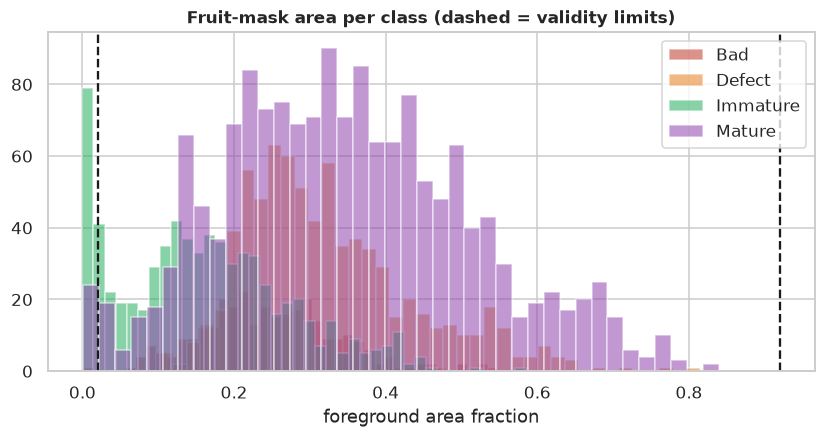

  ↳ figure saved: figures/fig06_mask_area.png (+ .pdf)


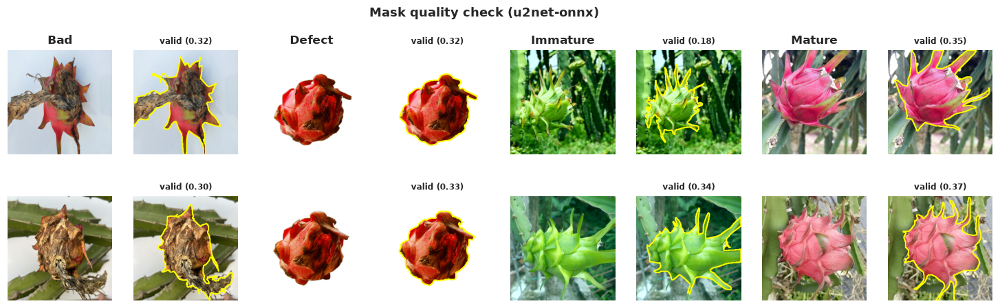

  ↳ figure saved: figures/fig07_mask_qc.png (+ .pdf)


In [7]:
# ── 7 · Foreground masks ──────────────────────────────────────────────────────
def _grabcut_mask(img):
    m = np.zeros(img.shape[:2], np.uint8)
    bgd, fgd = np.zeros((1, 65), np.float64), np.zeros((1, 65), np.float64)
    h, w = img.shape[:2]
    cv2.grabCut(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), m, (8, 8, w - 16, h - 16), bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
    return np.where((m == cv2.GC_FGD) | (m == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)

def get_mask_fn():
    """U²-Net salient-object mask with onnxruntime (same pre/post-processing as rembg). GrabCut fallback."""
    try:
        import onnxruntime as ort, urllib.request
        onnx_path = CACHE_DIR / "u2net.onnx"
        if not onnx_path.exists() or onnx_path.stat().st_size < 100e6:
            print(f"Downloading U²-Net model (176 MB) → {onnx_path}")
            urllib.request.urlretrieve(C.MASK_MODEL_URL, str(onnx_path) + ".part")
            os.replace(str(onnx_path) + ".part", onnx_path)
        so = ort.SessionOptions(); so.intra_op_num_threads = max(1, (os.cpu_count() or 4) - 2)
        sess = ort.InferenceSession(str(onnx_path), sess_options=so, providers=["CPUExecutionProvider"])
        in_name = sess.get_inputs()[0].name
        def _f(img):
            x = cv2.resize(img, (320, 320), interpolation=cv2.INTER_LANCZOS4).astype(np.float32)
            x = x / max(float(x.max()), 1e-6)
            x = ((x - np.array(MEAN, np.float32)) / np.array(STD, np.float32)).transpose(2, 0, 1)[None]
            p = sess.run(None, {in_name: x.astype(np.float32)})[0][0, 0]
            p = (p - p.min()) / max(float(p.max() - p.min()), 1e-6)
            return cv2.resize((p * 255).astype(np.uint8), img.shape[1::-1], interpolation=cv2.INTER_LANCZOS4)
        _f(IMGS[0])                                    # warm-up test
        return _f, "u2net-onnx"
    except Exception as e:
        print(f"⚠ U²-Net unavailable ({e}). Falling back to GrabCut – report this in the paper.")
        return _grabcut_mask, "grabcut"

def clean_mask(m):
    b = (m > 127).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(b, 8)
    if n > 1:
        b = (lab == (1 + np.argmax(st[1:, cv2.CC_STAT_AREA]))).astype(np.uint8)
    h, w = b.shape
    ff = np.pad(b, 1)                                  # 0-border guarantees the seed is background
    cv2.floodFill(ff, np.zeros((h + 4, w + 4), np.uint8), (0, 0), 1)
    b = b | (ff[1:-1, 1:-1] == 0).astype(np.uint8)     # pixels not reachable from outside = holes
    return (b * 255).astype(np.uint8)

MASK_PATH, MASK_META = CACHE_DIR / f"masks_{S}.npy", CACHE_DIR / f"masks_{S}.json"
_mask_sig = hashlib.md5("|".join(META.path).encode()).hexdigest()
_state = load_json(MASK_META) if MASK_META.exists() else {}
if not (MASK_PATH.exists() and _state.get("sig") == _mask_sig):
    _state = {"sig": _mask_sig, "done": 0, "method": None}
    np.lib.format.open_memmap(MASK_PATH, mode="w+", dtype=np.uint8, shape=(N, S, S)).flush()
    save_json(_state, MASK_META)

if _state["done"] < N:
    mask_fn, method = get_mask_fn()
    if _state["method"] not in (None, method):
        print(f"⚠ mask method changed ({_state['method']} → {method}); restarting masks")
        _state["done"] = 0
    _state["method"] = method
    mm = np.load(MASK_PATH, mmap_mode="r+")
    CH = 100
    with tqdm(total=N, initial=_state["done"], desc=f"Masks ({method})") as pbar:
        for s in range(_state["done"], N, CH):
            e = min(s + CH, N)
            for i in range(s, e):
                mm[i] = clean_mask(mask_fn(IMGS[i]))
            mm.flush(); _state["done"] = e; save_json(_state, MASK_META); pbar.update(e - s)
    del mm
MASK_METHOD = _state["method"]
MASKS = np.load(MASK_PATH)
AREA = (MASKS > 127).mean((1, 2))
VALID = (AREA >= C.MASK_MIN_AREA) & (AREA <= C.MASK_MAX_AREA)
META["mask_area"] = AREA; META["mask_valid"] = VALID
print(f"Mask method: {MASK_METHOD} | valid masks: {VALID.sum()}/{N} ({100 * VALID.mean():.1f}%)")
display(META.groupby("cls").agg(images=("path", "size"), valid_masks=("mask_valid", "sum"),
                                mean_area=("mask_area", "mean")).reindex(C.CLASSES).round(3))

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
for ci, cls in enumerate(C.CLASSES):
    ax.hist(AREA[LABELS == ci], bins=40, alpha=0.55, color=CLASS_COLORS[ci], label=cls)
for t in (C.MASK_MIN_AREA, C.MASK_MAX_AREA): ax.axvline(t, color="k", ls="--")
ax.set_xlabel("foreground area fraction"); ax.set_title("Fruit-mask area per class (dashed = validity limits)"); ax.legend()
save_fig(fig, "fig06_mask_area")

_rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 2 * K, figsize=(4.2 * K, 4.6))
for ci in range(K):
    for r, j in enumerate(_rng.choice(np.where(LABELS == ci)[0], 2, replace=False)):
        axes[r, 2 * ci].imshow(IMGS[j]); axes[r, 2 * ci].axis("off")
        ov = IMGS[j].copy(); cnt, _ = cv2.findContours((MASKS[j] > 127).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov, cnt, -1, (255, 255, 0), 2)
        axes[r, 2 * ci + 1].imshow(ov); axes[r, 2 * ci + 1].axis("off")
        axes[r, 2 * ci + 1].set_title(f"{'valid' if VALID[j] else 'INVALID'} ({AREA[j]:.2f})", fontsize=8)
    axes[0, 2 * ci].set_title(C.CLASSES[ci], fontsize=11, fontweight="bold")
fig.suptitle(f"Mask quality check ({MASK_METHOD})", fontweight="bold")
save_fig(fig, "fig07_mask_qc")

## 8 · Shortcut-audit views: **Foreground-only** and **Background-only** images
* **FG-only:** fruit kept, background replaced by neutral grey → *can the model classify from the fruit alone?* (higher = better)
* **BG-only:** fruit removed by in-painting → *can the model classify from the background alone?* (close to chance 25 % = good; high = shortcut)

✓ Loaded cache 'fg_only_256' from checkpoint
✓ Loaded cache 'bg_only_256' from checkpoint


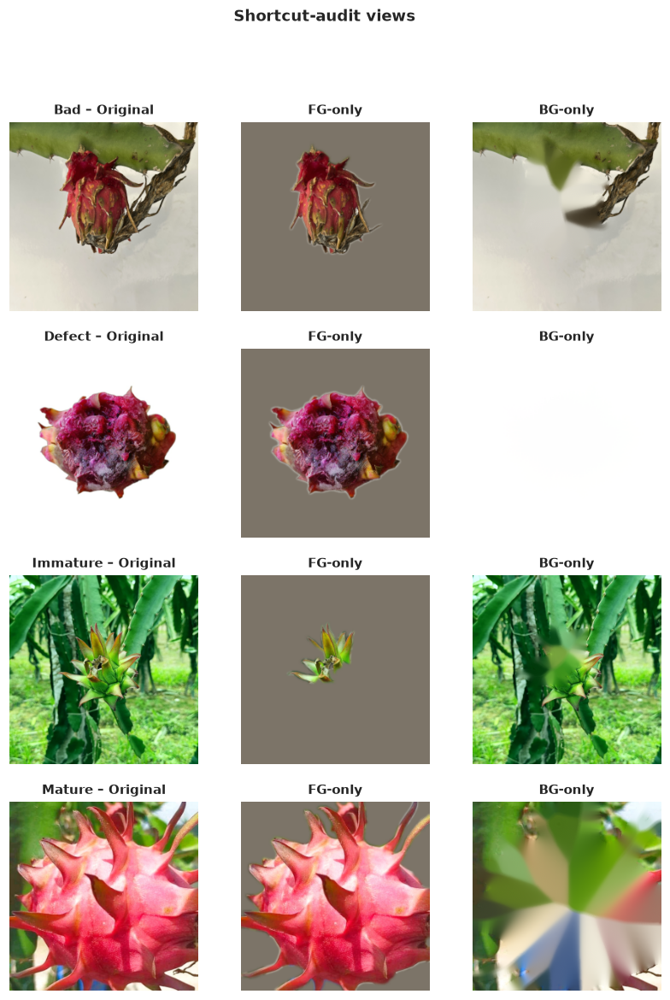

  ↳ figure saved: figures/fig08_audit_views.png (+ .pdf)


In [8]:
# ── 8 · FG-only / BG-only caches ──────────────────────────────────────────────
def make_fg_only(i):
    a = (cv2.GaussianBlur(MASKS[i], (7, 7), 0).astype(np.float32) / 255.0)[..., None]
    return np.clip(a * IMGS[i] + (1 - a) * GRAY_BG, 0, 255).astype(np.uint8)

def make_bg_only(i):
    if not VALID[i]:
        return IMGS[i]
    m = cv2.dilate((MASKS[i] > 127).astype(np.uint8) * 255, np.ones((9, 9), np.uint8))
    return cv2.inpaint(IMGS[i], m, 7, cv2.INPAINT_TELEA)

_mpaths = META.path.tolist()
_key = f"{MASK_METHOD}|{C.MASK_MIN_AREA}|{C.MASK_MAX_AREA}"
FGONLY = cached_array(f"fg_only_{S}", _mpaths, make_fg_only, (S, S, 3), desc="FG-only", key_extra=_key)
BGONLY = cached_array(f"bg_only_{S}", _mpaths, make_bg_only, (S, S, 3), desc="BG-only (in-paint)", key_extra=_key)

_rng = np.random.default_rng(1)
fig, axes = plt.subplots(K, 3, figsize=(9, 3 * K))
for ci in range(K):
    _c = np.where((LABELS == ci) & VALID)[0]
    j = _rng.choice(_c if len(_c) else np.where(LABELS == ci)[0])
    for c_, (im, t) in enumerate(((IMGS[j], "Original"), (FGONLY[j], "FG-only"), (BGONLY[j], "BG-only"))):
        axes[ci, c_].imshow(im); axes[ci, c_].axis("off")
        axes[ci, c_].set_title(f"{C.CLASSES[ci]} – {t}" if c_ == 0 else t, fontsize=10)
fig.suptitle("Shortcut-audit views", fontweight="bold")
save_fig(fig, "fig08_audit_views")

## 9 · Group-aware stratified 70 / 10 / 20 split + leakage verification (checkpointed)

✓ Loaded split from checkpoint

LEAKAGE VERIFICATION
  train × val  : path overlap=0  group overlap=0  md5 overlap=0  min pHash distance= 6  [OK]
  train × test : path overlap=0  group overlap=0  md5 overlap=0  min pHash distance= 6  [OK]
    val × test : path overlap=0  group overlap=0  md5 overlap=0  min pHash distance= 6  [OK]
  VERDICT: CLEAN ✓


,train,val,test,valid masks (test)
Bad,208,29,60,60
Defect,524,75,150,150
Immature,495,71,142,122
Mature,1111,159,317,315
TOTAL,2338,334,669,647


  ↳ table saved: tables/tab01_split.csv


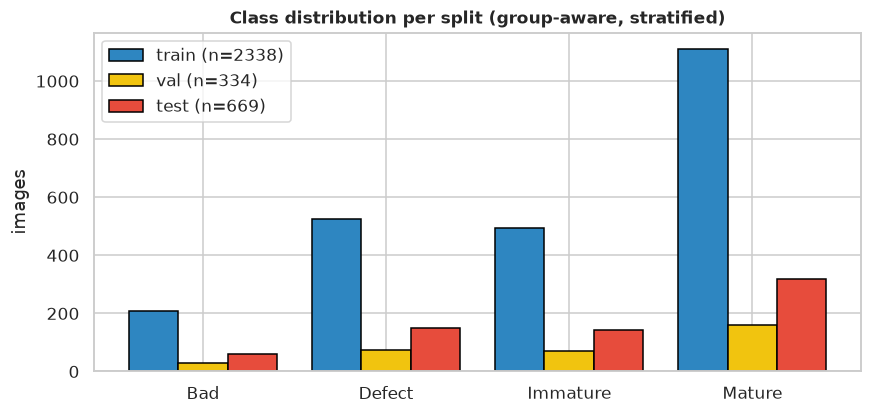

  ↳ figure saved: figures/fig09_split_distribution.png (+ .pdf)


In [9]:
# ── 9 · Split ─────────────────────────────────────────────────────────────────
def group_split(idx, frac, seed=42):
    n_splits = max(2, int(round(1 / frac)))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    a, b = next(sgkf.split(np.zeros(len(idx)), LABELS[idx], GROUPS[idx]))
    return np.sort(idx[a]), np.sort(idx[b])

SPLIT_PATH = CACHE_DIR / "split.json"
_split_sig = hashlib.md5(("|".join(META.path) + str(C.UNDERSAMPLE_TRAIN_TO)).encode()).hexdigest()
if SPLIT_PATH.exists() and load_json(SPLIT_PATH).get("sig") == _split_sig:
    _sp = load_json(SPLIT_PATH)
    SPLIT = {k: np.array(_sp[k], dtype=np.int64) for k in ("train", "val", "test")}
    print("✓ Loaded split from checkpoint")
else:
    _all = np.arange(N)
    trval, test = group_split(_all, C.TEST_FRAC)
    train, val = group_split(trval, C.VAL_FRAC / (1 - C.TEST_FRAC))
    if C.UNDERSAMPLE_TRAIN_TO:
        _r = np.random.default_rng(42); keep_tr = []
        for ci in range(K):
            ids = train[LABELS[train] == ci]
            keep_tr.append(ids if len(ids) <= C.UNDERSAMPLE_TRAIN_TO else _r.choice(ids, C.UNDERSAMPLE_TRAIN_TO, replace=False))
        train = np.sort(np.concatenate(keep_tr))
    SPLIT = {"train": train, "val": val, "test": test}
    save_json({"sig": _split_sig, **SPLIT}, SPLIT_PATH)

# ── Leakage verification ──
print("\nLEAKAGE VERIFICATION")
_ok = True
for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
    p_ov = len(set(META.path[SPLIT[a]]) & set(META.path[SPLIT[b]]))
    g_ov = len(set(GROUPS[SPLIT[a]]) & set(GROUPS[SPLIT[b]]))
    m_ov = len(set(META.md5[SPLIT[a]]) & set(META.md5[SPLIT[b]]))
    d_min = int(min(hamming_matrix_rows(HASH, SPLIT[b][s:s + 1024])[:, SPLIT[a]].min()
                    for s in range(0, len(SPLIT[b]), 1024)))
    flag = "OK" if (p_ov == 0 and g_ov == 0 and m_ov == 0 and d_min > C.PHASH_HAMMING) else "FAIL"
    _ok &= flag == "OK"
    print(f"  {a:>5} × {b:<5}: path overlap={p_ov}  group overlap={g_ov}  md5 overlap={m_ov}  "
          f"min pHash distance={d_min:>2}  [{flag}]")
assert _ok, "Leakage detected – do not continue."
print("  VERDICT: CLEAN ✓")

_tab = pd.DataFrame({s: np.bincount(LABELS[SPLIT[s]], minlength=K) for s in SPLIT}, index=C.CLASSES)
_tab.loc["TOTAL"] = _tab.sum()
_tab["valid masks (test)"] = list(np.bincount(LABELS[SPLIT["test"]][VALID[SPLIT["test"]]], minlength=K)) + [int(VALID[SPLIT["test"]].sum())]
display(_tab)
save_table(_tab.reset_index().rename(columns={"index": "class"}), "tab01_split", "Group-aware stratified split")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(K); w = 0.27
for si, (s, col) in enumerate(zip(("train", "val", "test"), ("#2E86C1", "#F1C40F", "#E74C3C"))):
    v = np.bincount(LABELS[SPLIT[s]], minlength=K)
    ax.bar(x + (si - 1) * w, v, w, label=f"{s} (n={len(SPLIT[s])})", color=col, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(C.CLASSES); ax.set_ylabel("images"); ax.legend()
ax.set_title("Class distribution per split (group-aware, stratified)")
save_fig(fig, "fig09_split_distribution")

## 10 · GPU-resident data pipeline (no CPU workers → no hang, GPU never waits) + **Cross-Class Background Swap (CCBS)**
**Why:** forked CPU `DataLoader` workers froze on the DGX Spark (GPU sat idle). Now every cached image, mask and audit view lives in GPU memory
(~3.5 GB of the 128 GB), and **all augmentation runs as batched GPU tensor ops**:
class-balanced sampling (`torch.multinomial`) → CCBS → one random affine per image (random-resized-crop 0.70–1.0, h-flip 0.5, v-flip 0.3,
rotation ±30° with p = 0.5, applied **jointly to image + mask**) → colour jitter (p = 0.6; brightness/contrast ±0.2, saturation ±0.15,
hue ±0.02) → Gaussian blur (p = 0.2, σ 0.1–1.5) → normalise → random erasing (p = 0.25, 2–10 % area).
All randomness comes from a seeded CUDA generator whose state is saved in every checkpoint → exact resume.

Dataset copied to cuda: 2.63 GB in 0.5s


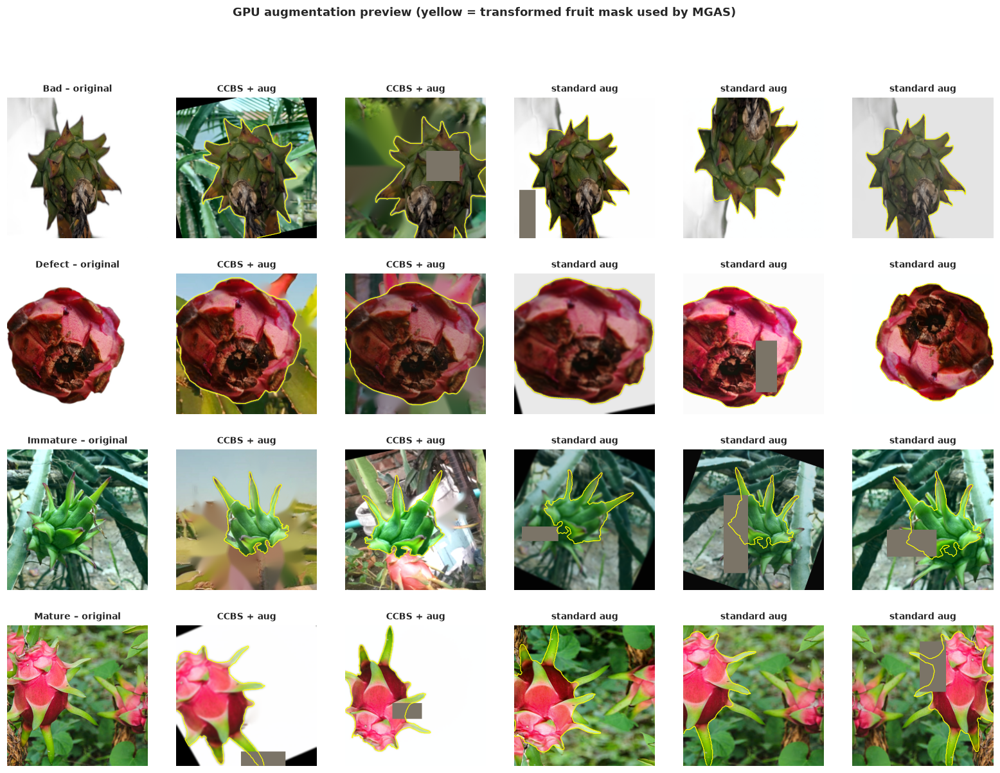

  ↳ figure saved: figures/fig10_augmentation_preview.png (+ .pdf)
Batch on cuda:0: images (64, 3, 224, 224) torch.float32 range [-2.12, 2.64] | labels (64,) | masks (64, 1, 224, 224) | valid 59/64
  train (aug + CCBS)  : 2,162 images/s
  eval                : 8,809 images/s


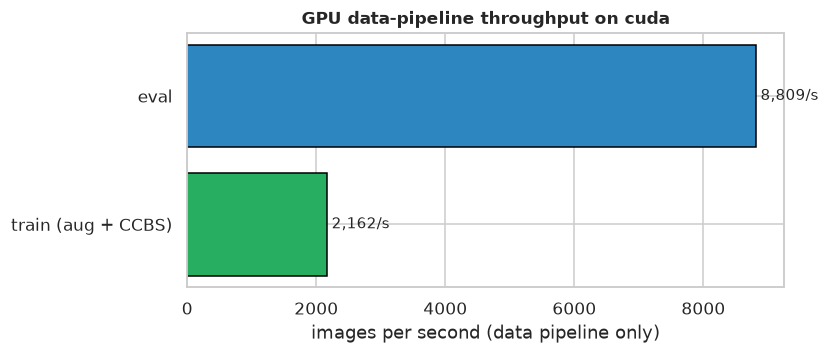

  ↳ figure saved: figures/fig10b_pipeline_throughput.png (+ .pdf)
GPU memory in use: 2.81 GB
GPU data pipeline ready ✓


In [10]:
# ── 10 · GPU data pipeline ────────────────────────────────────────────────────
def to_gpu_nchw(a):
    return torch.from_numpy(np.ascontiguousarray(a)).to(DEVICE).permute(0, 3, 1, 2).contiguous()

t0 = time.time()
GPU_IMG = {"clean": to_gpu_nchw(IMGS), "fg": to_gpu_nchw(FGONLY), "bg": to_gpu_nchw(BGONLY)}   # uint8 N×3×S×S
GPU_MASK = torch.from_numpy(MASKS).to(DEVICE)[:, None]                                           # uint8 N×1×S×S
_ab = torch.tensor(cv2.getGaussianKernel(7, 0).ravel(), dtype=torch.float32, device=DEVICE)
GPU_ALPHA = torch.empty(GPU_MASK.shape, dtype=torch.float16, device=DEVICE)                     # soft alpha for CCBS
for s in range(0, N, 512):                                                                       # 7×7 Gaussian feathering
    mm_ = GPU_MASK[s:s + 512].float() / 255.0
    mm_ = F.conv2d(F.pad(mm_, (3, 3, 0, 0), mode="replicate"), _ab.view(1, 1, 1, 7))
    GPU_ALPHA[s:s + 512] = F.conv2d(F.pad(mm_, (0, 0, 3, 3), mode="replicate"), _ab.view(1, 1, 7, 1)).half()
LABELS_T = torch.as_tensor(LABELS, device=DEVICE)
VALID_T = torch.as_tensor(VALID, device=DEVICE)
MEAN_T = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
STD_T = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
if DEVICE.type == "cuda": torch.cuda.synchronize()
_gb = sum(t.numel() * t.element_size() for t in (*GPU_IMG.values(), GPU_MASK, GPU_ALPHA)) / 1e9
print(f"Dataset copied to {DEVICE}: {_gb:.2f} GB in {time.time() - t0:.1f}s")

def _u(n, lo, hi, g):
    return torch.rand(n, device=DEVICE, generator=g) * (hi - lo) + lo

def gpu_affine(x, m, g, out=C.IMG_SIZE):
    """Random-resized-crop + flips + rotation as ONE affine warp per sample (image & mask share the warp)."""
    B = x.shape[0]
    area = _u(B, 0.70, 1.0, g)
    logr = _u(B, math.log(0.85), math.log(1.18), g)
    sw = torch.sqrt(area * torch.exp(logr)).clamp(max=1.0)
    sh = torch.sqrt(area / torch.exp(logr)).clamp(max=1.0)
    tx = (torch.rand(B, device=DEVICE, generator=g) * 2 - 1) * (1 - sw)
    ty = (torch.rand(B, device=DEVICE, generator=g) * 2 - 1) * (1 - sh)
    fx = torch.where(torch.rand(B, device=DEVICE, generator=g) < 0.5, -1.0, 1.0)
    fy = torch.where(torch.rand(B, device=DEVICE, generator=g) < 0.3, -1.0, 1.0)
    ang = torch.where(torch.rand(B, device=DEVICE, generator=g) < 0.5, _u(B, -30, 30, g), torch.zeros(B, device=DEVICE))
    ang = ang * math.pi / 180
    cos, sin = torch.cos(ang), torch.sin(ang)
    theta = torch.stack([torch.stack([cos * sw * fx, -sin * sh * fy, tx], 1),
                         torch.stack([sin * sw * fx, cos * sh * fy, ty], 1)], 1)
    grid = F.affine_grid(theta, (B, 1, out, out), align_corners=False)
    return (F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False),
            F.grid_sample(m, grid, mode="bilinear", padding_mode="zeros", align_corners=False))

def gpu_colour(x, g, p=0.6):
    B = x.shape[0]
    on = (torch.rand(B, device=DEVICE, generator=g) < p).float().view(B, 1, 1, 1)
    b = 1 + on * _u(B, -0.20, 0.20, g).view(B, 1, 1, 1)
    c = 1 + on * _u(B, -0.20, 0.20, g).view(B, 1, 1, 1)
    s = 1 + on * _u(B, -0.15, 0.15, g).view(B, 1, 1, 1)
    h = on.view(B) * _u(B, -0.02, 0.02, g) * 2 * math.pi
    x = (x * b).clamp(0, 1)
    gray = (0.299 * x[:, 0] + 0.587 * x[:, 1] + 0.114 * x[:, 2])[:, None]
    x = ((x - gray.mean((2, 3), keepdim=True)) * c + gray.mean((2, 3), keepdim=True)).clamp(0, 1)
    gray = (0.299 * x[:, 0] + 0.587 * x[:, 1] + 0.114 * x[:, 2])[:, None]
    x = ((x - gray) * s + gray).clamp(0, 1)
    r, gg, bb = x[:, 0], x[:, 1], x[:, 2]                        # hue rotation in YIQ space
    Y = 0.299 * r + 0.587 * gg + 0.114 * bb
    I = 0.596 * r - 0.274 * gg - 0.322 * bb
    Q = 0.211 * r - 0.523 * gg + 0.312 * bb
    ch, sh_ = torch.cos(h).view(B, 1, 1), torch.sin(h).view(B, 1, 1)
    I, Q = I * ch - Q * sh_, I * sh_ + Q * ch
    x = torch.stack([Y + 0.956 * I + 0.621 * Q, Y - 0.272 * I - 0.647 * Q, Y - 1.106 * I + 1.703 * Q], 1)
    return x.clamp(0, 1)

def gpu_blur(x, g, p=0.2):
    B = x.shape[0]
    sel = torch.rand(B, device=DEVICE, generator=g) < p
    n = int(sel.sum())
    if n == 0:
        return x
    sig = _u(n, 0.1, 1.5, g)
    k = torch.arange(-2, 3, device=DEVICE, dtype=torch.float32)
    ker = torch.exp(-(k[None] ** 2) / (2 * sig[:, None] ** 2)); ker = ker / ker.sum(1, keepdim=True)
    ker = ker.repeat_interleave(3, 0)                             # (n*3, 5)
    xs = x[sel].reshape(1, n * 3, *x.shape[-2:])
    xs = F.conv2d(F.pad(xs, (2, 2, 0, 0), mode="reflect"), ker.view(n * 3, 1, 1, 5), groups=n * 3)
    xs = F.conv2d(F.pad(xs, (0, 0, 2, 2), mode="reflect"), ker.view(n * 3, 1, 5, 1), groups=n * 3)
    x = x.clone(); x[sel] = xs.view(n, 3, *x.shape[-2:])
    return x

def gpu_erase(x, g, p=0.25):
    B, _, H, W = x.shape
    sel = (torch.rand(B, device=DEVICE, generator=g) < p).view(B, 1, 1)
    area = _u(B, 0.02, 0.10, g) * H * W
    r = torch.exp(_u(B, math.log(0.3), math.log(3.3), g))
    eh = torch.sqrt(area * r).clamp(1, H - 1); ew = torch.sqrt(area / r).clamp(1, W - 1)
    top = torch.rand(B, device=DEVICE, generator=g) * (H - eh); left = torch.rand(B, device=DEVICE, generator=g) * (W - ew)
    yy = torch.arange(H, device=DEVICE).view(1, H, 1); xx = torch.arange(W, device=DEVICE).view(1, 1, W)
    box = (yy >= top.view(B, 1, 1)) & (yy < (top + eh).view(B, 1, 1)) & (xx >= left.view(B, 1, 1)) & (xx < (left + ew).view(B, 1, 1))
    return x.masked_fill((box & sel)[:, None], 0.0)

class GPULoader:
    """Yields (image, label, mask, mask_valid) batches that are already on the GPU."""
    def __init__(self, idx, source="clean", train=False, seed=0, bgswap_p=0.0, bg_pool_idx=None, batch_size=None):
        self.idx = torch.as_tensor(np.asarray(idx, dtype=np.int64), device=DEVICE)
        self.src, self.train, self.p = source, train, float(bgswap_p)
        self.bs = batch_size or (C.BATCH_SIZE if train else C.EVAL_BATCH_SIZE)
        self.gen = torch.Generator(device=DEVICE); self.gen.manual_seed(int(seed))
        self.pool = None
        if train:
            cnt = torch.bincount(LABELS_T[self.idx], minlength=K).float().clamp_min(1)
            self.w = (1.0 / cnt)[LABELS_T[self.idx]]                      # class-balanced sampling weights
            if self.p > 0 and bg_pool_idx is not None and len(bg_pool_idx) > 0:
                bp = torch.as_tensor(np.asarray(bg_pool_idx, dtype=np.int64), device=DEVICE)
                self.pool = [bp[LABELS_T[bp] != c] for c in range(K)]

    def __len__(self):
        return len(self.idx) // self.bs if self.train else math.ceil(len(self.idx) / self.bs)

    def state_dict(self):  return {"gen": self.gen.get_state()}
    def load_state_dict(self, d): self.gen.set_state(d["gen"].cpu() if hasattr(d["gen"], "cpu") else d["gen"])

    def __iter__(self):
        if self.train:
            order = self.idx[torch.multinomial(self.w, len(self.idx), replacement=True, generator=self.gen)]
            for b in range(len(self)):
                yield self._train_batch(order[b * self.bs:(b + 1) * self.bs])
        else:
            for b in range(len(self)):
                yield self._eval_batch(self.idx[b * self.bs:(b + 1) * self.bs])

    def _eval_batch(self, j):
        x = GPU_IMG[self.src][j].float() / 255.0
        x = F.interpolate(x, size=(C.IMG_SIZE, C.IMG_SIZE), mode="bilinear", antialias=True, align_corners=False)
        m = F.interpolate(GPU_MASK[j].float() / 255.0, size=(C.IMG_SIZE, C.IMG_SIZE), mode="bilinear", align_corners=False)
        x = ((x - MEAN_T) / STD_T).contiguous(memory_format=torch.channels_last)
        return x, LABELS_T[j], m, VALID_T[j].float()

    def _train_batch(self, j):
        g, B = self.gen, len(j)
        x = GPU_IMG[self.src][j].float() / 255.0
        m = GPU_MASK[j].float() / 255.0
        y, v = LABELS_T[j], VALID_T[j]
        if self.pool is not None:                                            # CCBS
            do = (torch.rand(B, device=DEVICE, generator=g) < self.p) & v
            if bool(do.any()):
                bg_idx = j.clone()
                for c in range(K):
                    sel = do & (y == c)
                    n = int(sel.sum())
                    if n and len(self.pool[c]):
                        bg_idx[sel] = self.pool[c][torch.randint(len(self.pool[c]), (n,), device=DEVICE, generator=g)]
                    elif n:
                        do = do & ~sel
                bg = GPU_IMG["bg"][bg_idx].float() / 255.0
                bg = torch.where((torch.rand(B, device=DEVICE, generator=g) < 0.5).view(B, 1, 1, 1), bg.flip(-1), bg)
                a = GPU_ALPHA[j].float()
                x = torch.where(do.view(B, 1, 1, 1), a * x + (1 - a) * bg, x)
        x, m = gpu_affine(x, m, g)
        x = gpu_blur(gpu_colour(x, g), g)
        x = gpu_erase((x - MEAN_T) / STD_T, g)
        return x.contiguous(memory_format=torch.channels_last), y, m, v.float()

def denorm(x):
    x = x.detach().float().cpu().numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN)
    return np.clip(x, 0, 1)

# ── Figure: augmentation preview (original | 2× CCBS+aug | 3× standard aug; yellow = transformed mask) ──
_pool = SPLIT["train"][VALID[SPLIT["train"]]]
fig, axes = plt.subplots(K, 6, figsize=(18, 3.1 * K))
for ci in range(K):
    pos = SPLIT["train"][(LABELS[SPLIT["train"]] == ci) & VALID[SPLIT["train"]]]
    j = int((pos if len(pos) else SPLIT["train"][LABELS[SPLIT["train"]] == ci])[0])
    axes[ci, 0].imshow(IMGS[j]); axes[ci, 0].set_title(f"{C.CLASSES[ci]} – original", fontsize=9)
    for c_ in range(1, 6):
        ld = GPULoader([j], train=True, seed=100 * ci + c_, bgswap_p=1.0 if c_ <= 2 else 0.0,
                       bg_pool_idx=_pool, batch_size=1)
        xb_, _, mb_, _ = ld._train_batch(ld.idx)
        axes[ci, c_].imshow(denorm(xb_[0]))
        axes[ci, c_].contour(mb_[0, 0].float().cpu().numpy(), levels=[0.5], colors="yellow", linewidths=0.8)
        axes[ci, c_].set_title("CCBS + aug" if c_ <= 2 else "standard aug", fontsize=9)
    for a in axes[ci]: a.axis("off")
fig.suptitle("GPU augmentation preview (yellow = transformed fruit mask used by MGAS)", fontweight="bold")
save_fig(fig, "fig10_augmentation_preview")

# ── Throughput benchmark: how fast the GPU pipeline feeds the model ──
_ld = GPULoader(SPLIT["train"], train=True, seed=0, bgswap_p=0.5, bg_pool_idx=_pool)
xb, yb, mb, vb = next(iter(_ld))
print(f"Batch on {xb.device}: images {tuple(xb.shape)} {xb.dtype} range [{xb.min():.2f}, {xb.max():.2f}] | "
      f"labels {tuple(yb.shape)} | masks {tuple(mb.shape)} | valid {int(vb.sum())}/{len(vb)}")
_rates = {}
for name_, kw_ in (("train (aug + CCBS)", dict(train=True, bgswap_p=0.5, bg_pool_idx=_pool)), ("eval", dict())):
    ld = GPULoader(SPLIT["train"], seed=1, **kw_)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0, n_ = time.time(), 0
    for xb_, *_ in ld:
        n_ += xb_.shape[0]
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    _rates[name_] = n_ / (time.time() - t0)
    print(f"  {name_:<20}: {_rates[name_]:,.0f} images/s")
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(_rates), list(_rates.values()), color=["#27AE60", "#2E86C1"], edgecolor="black")
for i, v_ in enumerate(_rates.values()): ax.text(v_, i, f" {v_:,.0f}/s", va="center")
ax.set_xlabel("images per second (data pipeline only)"); ax.set_title(f"GPU data-pipeline throughput on {DEVICE}")
save_fig(fig, "fig10b_pipeline_throughput")
if DEVICE.type == "cuda":
    print(f"GPU memory in use: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
del _ld, xb, yb, mb, vb
print("GPU data pipeline ready ✓")

## 11 · Model: DFCViT-4C (+ ablation switches) and the MGAS loss
`forward(x, return_attn=True)` also returns the CBAM spatial attention map (B×1×7×7) that MGAS supervises.

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


DFCViT-4C: logits (2, 4) | attention (2, 1, 7, 7)
  MobileNetV2 backbone  :  1,811,712
  Projection            :     82,432
  CBAM                  :     16,482
  Transformer           :  1,054,720
  Head                  :     33,924
  Tokens/pos-emb        :     13,056
  TOTAL                 :  3,012,326  (3.01 M)


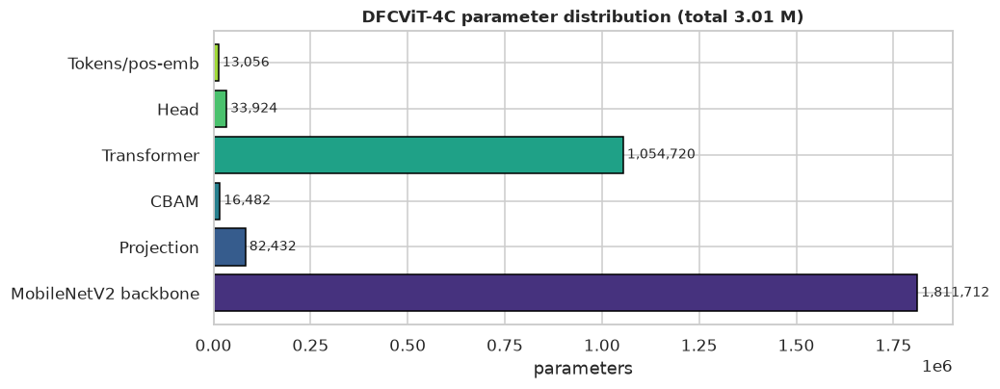

  ↳ figure saved: figures/fig11_model_parameters.png (+ .pdf)


In [11]:
# ── 11 · Architecture ─────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, ch, ratio=8):
        super().__init__()
        mid = max(1, ch // ratio)
        self.mlp = nn.Sequential(nn.Linear(ch, mid, bias=False), nn.ReLU(inplace=True), nn.Linear(mid, ch, bias=False))
    def forward(self, x):
        b, c = x.shape[:2]
        w = torch.sigmoid(self.mlp(x.mean((2, 3))) + self.mlp(x.amax((2, 3))))
        return x * w.view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)
    def forward(self, x):
        att = torch.sigmoid(self.conv(torch.cat([x.mean(1, keepdim=True), x.amax(1, keepdim=True)], 1)))
        return x * att, att

class CBAM(nn.Module):
    def __init__(self, ch, ratio=8, k=7):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, ratio), SpatialAttention(k)
    def forward(self, x):
        return self.sa(self.ca(x))

class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__(); self.p = p
    def forward(self, x):
        if self.p == 0.0 or not self.training:
            return x
        keep = 1 - self.p
        mask = x.new_empty((x.shape[0],) + (1,) * (x.ndim - 1)).bernoulli_(keep)
        return x * mask / keep

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=2.0, drop=0.1, drop_path=0.0):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        h = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Dropout(drop), nn.Linear(h, dim), nn.Dropout(drop))
        self.dp = DropPath(drop_path)
    def forward(self, x):
        n = self.n1(x)
        x = x + self.dp(self.attn(n, n, n, need_weights=False)[0])
        return x + self.dp(self.ffn(self.n2(x)))

class DFCViT4C(nn.Module):
    """MobileNetV2 → 1×1 projection → CBAM → CLS-token Transformer → MLP head."""
    def __init__(self, num_classes=4, backbone="mobilenetv2_100", embed_dim=256, heads=8, depth=2,
                 dropout=0.3, drop_path=0.1, img_size=224, pretrained=True, use_cbam=True, use_transformer=True):
        super().__init__()
        self.use_cbam, self.use_transformer = use_cbam, use_transformer
        self.backbone = timm.create_model(backbone, pretrained=pretrained, features_only=True, out_indices=(4,))
        in_ch = self.backbone.feature_info.channels()[-1]
        with torch.no_grad():
            fh, fw = self.backbone(torch.zeros(1, 3, img_size, img_size))[-1].shape[-2:]
        self.proj = nn.Sequential(nn.Conv2d(in_ch, embed_dim, 1, bias=False), nn.BatchNorm2d(embed_dim), nn.GELU())
        self.cbam = CBAM(embed_dim) if use_cbam else None
        if use_transformer:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
            self.pos_embed = nn.Parameter(torch.zeros(1, fh * fw + 1, embed_dim))
            self.pos_drop = nn.Dropout(dropout * 0.5)
            dpr = torch.linspace(0, drop_path, depth).tolist()
            self.blocks = nn.ModuleList([TransformerBlock(embed_dim, heads, 2.0, dropout * 0.5, dpr[i]) for i in range(depth)])
            self.norm = nn.LayerNorm(embed_dim)
            nn.init.trunc_normal_(self.cls_token, std=0.02); nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.head_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(nn.Linear(embed_dim, embed_dim // 2), nn.GELU(), nn.Dropout(dropout),
                                        nn.Linear(embed_dim // 2, num_classes))

    def forward(self, x, return_attn: bool = False):
        f = self.proj(self.backbone(x)[-1])
        att = None
        if self.cbam is not None:
            f, att = self.cbam(f)
        if self.use_transformer:
            t = torch.cat([self.cls_token.expand(f.shape[0], -1, -1), f.flatten(2).transpose(1, 2)], 1)
            t = self.pos_drop(t + self.pos_embed)
            for blk in self.blocks:
                t = blk(t)
            z = self.norm(t)[:, 0]
        else:
            z = f.mean((2, 3))
        logits = self.classifier(self.head_norm(z))
        return (logits, att) if return_attn else logits

class FocalLoss(nn.Module):
    """Focal loss with label smoothing (no class weights – imbalance handled by the sampler)."""
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__(); self.g, self.s = gamma, smoothing
    def forward(self, logits, target):
        logits = logits.float()
        logp = F.log_softmax(logits, -1)
        with torch.no_grad():
            q = torch.full_like(logp, self.s / (logits.shape[-1] - 1))
            q.scatter_(1, target[:, None], 1.0 - self.s)
        pt = logp.gather(1, target[:, None]).squeeze(1).exp().clamp(1e-6, 1.0)
        return ((1 - pt) ** self.g * -(q * logp).sum(-1)).mean()

def mgas_loss(att, mask, valid):
    """Mask-Guided Attention Supervision: BCE between CBAM spatial attention and the down-sampled fruit mask."""
    with torch.autocast(device_type=DEVICE.type, enabled=False):
        tgt = F.adaptive_avg_pool2d(mask.float(), att.shape[-2:])
        per = F.binary_cross_entropy(att.float().clamp(1e-6, 1 - 1e-6), tgt, reduction="none").mean((1, 2, 3))
        return (per * valid).sum() / valid.sum().clamp_min(1.0)

def build_dfcvit(hp, use_cbam=True, use_transformer=True, pretrained=None):
    return DFCViT4C(K, C.BACKBONE, C.EMBED_DIM, C.NUM_HEADS, C.DEPTH, hp["dropout"], hp["drop_path"],
                    C.IMG_SIZE, C.PRETRAINED if pretrained is None else pretrained, use_cbam, use_transformer)

def build_timm(timm_id):
    def _b(hp, pretrained=None):
        return timm.create_model(timm_id, pretrained=C.PRETRAINED if pretrained is None else pretrained, num_classes=K)
    return _b

def n_params(m):
    return sum(p.numel() for p in m.parameters())

# Unit test + parameter figure
_m = build_dfcvit(C.DEFAULT_HP).to(DEVICE).eval()
with torch.no_grad():
    _lo, _at = _m(torch.randn(2, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE), return_attn=True)
print(f"DFCViT-4C: logits {tuple(_lo.shape)} | attention {tuple(_at.shape)}")
_parts = {"MobileNetV2 backbone": _m.backbone, "Projection": _m.proj, "CBAM": _m.cbam,
          "Transformer": nn.ModuleList([_m.blocks, _m.norm]), "Head": nn.ModuleList([_m.head_norm, _m.classifier])}
_pc = {k: n_params(v) for k, v in _parts.items()}
_pc["Tokens/pos-emb"] = _m.cls_token.numel() + _m.pos_embed.numel()
for k, v in _pc.items(): print(f"  {k:<22}: {v:>10,}")
print(f"  {'TOTAL':<22}: {n_params(_m):>10,}  ({n_params(_m) / 1e6:.2f} M)")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(list(_pc), list(_pc.values()), color=sns.color_palette("viridis", len(_pc)), edgecolor="black")
for i, v in enumerate(_pc.values()): ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_title(f"DFCViT-4C parameter distribution (total {n_params(_m) / 1e6:.2f} M)"); ax.set_xlabel("parameters")
save_fig(fig, "fig11_model_parameters")
del _m; gc.collect(); torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

## 12 · Shared training engine (used by **every** model) — checkpoint every epoch, resume, validation-only selection
* Optimiser AdamW, pretrained part at 0.1× LR, no weight-decay on norms/biases/tokens.
* Schedule: linear warm-up `(ep+1)/W` (**fixed**: epoch 1 no longer has LR = 0) → cosine.
* Loss: focal + label smoothing (+ λ·MGAS for DFCViT); MixUp (masks are mixed too); bf16 autocast; grad-clip 1.0.
* **Checkpoint selection = best validation macro-F1 (tie → lower val NLL). Early stopping = validation NLL.** The test set is evaluated once, after training.
* Files per run: `checkpoints/<run>/last.pt` (every epoch, for resume), `best.pt`, `result.json` (run is skipped when it exists).

In [12]:
# ── 12 · Training engine ──────────────────────────────────────────────────────
def param_groups(model, lr, wd):
    if hasattr(model, "backbone"):
        bb_ids = {id(p) for p in model.backbone.parameters()}
    else:
        head_ids = {id(p) for p in model.get_classifier().parameters()}
        bb_ids = {id(p) for p in model.parameters() if id(p) not in head_ids}
    groups = {}
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        is_bb = id(p) in bb_ids
        no_wd = p.ndim <= 1 or "token" in name or "pos_embed" in name
        key = (is_bb, no_wd)
        groups.setdefault(key, dict(params=[], lr=lr * (C.BACKBONE_LR_MULT if is_bb else 1.0),
                                    weight_decay=0.0 if no_wd else wd))
        groups[key]["params"].append(p)
    return list(groups.values())

def make_scheduler(opt, epochs, warmup):
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        return 0.5 * (1 + math.cos(math.pi * (ep - warmup) / max(1, epochs - warmup)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    L, Y = [], []
    for x, y, _, _ in loader:
        with autocast_ctx():
            out = model(x)
        L.append(out.float().cpu()); Y.append(y.cpu())
    L, Y = torch.cat(L), torch.cat(Y)
    P = L.softmax(1).numpy(); pred = P.argmax(1); y = Y.numpy()
    return dict(nll=float(F.cross_entropy(L, Y)), acc=float(accuracy_score(y, pred)),
                macro_f1=float(f1_score(y, pred, average="macro", zero_division=0)),
                preds=pred, probs=P, labels=y)

def train_one_epoch(model, loader, crit, opt, scaler, hp, rng, use_mgas):
    model.train()
    tot = corr = n = 0.0; mg_tot = 0.0
    for x, y, m, v in loader:
        mix = hp["mixup_alpha"] > 0 and rng.random() < C.MIXUP_P
        if mix:
            lam = float(rng.beta(hp["mixup_alpha"], hp["mixup_alpha"]))
            perm = torch.randperm(x.shape[0], device=DEVICE)
            x = lam * x + (1 - lam) * x[perm]; m = lam * m + (1 - lam) * m[perm]; v = v * v[perm]
            yb = y[perm]
        opt.zero_grad(set_to_none=True)
        with autocast_ctx():
            if use_mgas:
                logits, att = model(x, return_attn=True)
            else:
                logits, att = model(x), None
        loss = lam * crit(logits, y) + (1 - lam) * crit(logits, yb) if mix else crit(logits, y)
        if use_mgas and att is not None:
            lm = mgas_loss(att, m, v)
            loss = loss + hp["mgas_lambda"] * lm
            mg_tot += lm.detach().item() * x.shape[0]
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), C.GRAD_CLIP)
        scaler.step(opt); scaler.update()
        pred = logits.detach().argmax(1)
        corr += float(((pred == y).float() * lam + (pred == yb).float() * (1 - lam)).sum() if mix else (pred == y).sum())
        tot += loss.detach().item() * x.shape[0]; n += x.shape[0]
    return tot / n, corr / n, mg_tot / n

def _cuda_rng():
    return torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None

def run_training(run_name, build_fn, hp, split, seed, epochs, *, use_mgas=False, bgswap_p=0.0,
                 trial=None, eval_test=True, verbose=True):
    """Train one model with the shared recipe. Fully resumable; returns a result dict."""
    rdir = CKPT_DIR / run_name; rdir.mkdir(parents=True, exist_ok=True)
    res_path, last_path, best_path = rdir / "result.json", rdir / "last.pt", rdir / "best.pt"
    if res_path.exists():
        r = load_json(res_path)
        if verbose:
            print(f"✓ [{run_name}] loaded from checkpoint (best epoch {r['best_epoch']}, "
                  f"val F1 {r['best_val_f1']:.4f}, test acc {r.get('test', {}).get('clean', {}).get('acc', float('nan')):.4f})")
        return r

    set_seed(seed)
    hp = {**C.DEFAULT_HP, **hp}
    model = build_fn(hp).to(DEVICE, memory_format=torch.channels_last)
    crit = FocalLoss(C.FOCAL_GAMMA, C.LABEL_SMOOTHING)
    opt = torch.optim.AdamW(param_groups(model, hp["lr"], hp["weight_decay"]), fused=DEVICE.type == "cuda")
    sched = make_scheduler(opt, epochs, C.WARMUP_EPOCHS)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=(AMP_DTYPE == torch.float16))
    rng = np.random.default_rng(seed)
    use_mgas = use_mgas and hp["mgas_lambda"] > 0
    pool = split["train"][VALID[split["train"]]] if bgswap_p > 0 else None
    tr_dl = GPULoader(split["train"], train=True, seed=seed, bgswap_p=bgswap_p, bg_pool_idx=pool)
    va_idx = split["val"]; va_fg_idx = va_idx[VALID[va_idx]]
    if len(va_fg_idx) == 0: va_fg_idx = va_idx
    va_dl, vafg_dl = GPULoader(va_idx), GPULoader(va_fg_idx, source="fg")

    hist = {k: [] for k in ("lr", "tr_loss", "tr_acc", "tr_mgas", "va_nll", "va_acc", "va_f1",
                            "vafg_nll", "vafg_acc", "time")}
    start, best_key, best_epoch, best_obj, es_best, es_count = 0, (-1.0, 0.0), -1, float("inf"), float("inf"), 0
    if last_path.exists():
        ck = torch.load(last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); sched.load_state_dict(ck["sched"])
        scaler.load_state_dict(ck["scaler"]); hist = ck["hist"]; start = ck["epoch"] + 1
        best_key, best_epoch, best_obj = tuple(ck["best_key"]), ck["best_epoch"], ck["best_obj"]
        es_best, es_count = ck["es_best"], ck["es_count"]
        tr_dl.load_state_dict(ck["loader"])
        rng.bit_generator.state = ck["np_rng"]
        torch.set_rng_state(ck["torch_rng"].cpu().to(torch.uint8))       # map_location moved it to the GPU → back to CPU
        if ck["cuda_rng"] is not None: torch.cuda.set_rng_state_all([s.cpu().to(torch.uint8) for s in ck["cuda_rng"]])
        print(f"↻ [{run_name}] RESUMING from checkpoint {last_path} at epoch {start + 1}")
    elif verbose:
        print(f"▶ [{run_name}] new run | checkpoint dir: {rdir}")
    if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()

    t_run = time.time()
    try:
        for ep in range(start, epochs):
            if DEVICE.type == "cuda": torch.cuda.synchronize()
            t0 = time.time()
            lr_now = opt.param_groups[-1]["lr"]
            tl, ta, tm = train_one_epoch(model, tr_dl, crit, opt, scaler, hp, rng, use_mgas)
            if DEVICE.type == "cuda": torch.cuda.synchronize()
            ips = len(tr_dl) * tr_dl.bs / (time.time() - t0)
            va, vf = evaluate(model, va_dl), evaluate(model, vafg_dl)
            sched.step()
            for k_, v_ in zip(hist, (lr_now, tl, ta, tm, va["nll"], va["acc"], va["macro_f1"],
                                     vf["nll"], vf["acc"], time.time() - t0)):
                hist[k_].append(v_)
            obj = 0.5 * (va["nll"] + vf["nll"])          # tuning objective: clean + foreground-only validation NLL
            best_obj = min(best_obj, obj)
            key = (va["macro_f1"], -va["nll"])
            star = ""
            if key > best_key:
                best_key, best_epoch, star = key, ep, " ★"
                atomic_torch_save(model.state_dict(), best_path)
            if va["nll"] < es_best - 1e-4: es_best, es_count = va["nll"], 0
            else: es_count += 1
            atomic_torch_save(dict(model=model.state_dict(), opt=opt.state_dict(), sched=sched.state_dict(),
                                   scaler=scaler.state_dict(), hist=hist, epoch=ep, best_key=list(best_key),
                                   best_epoch=best_epoch, best_obj=best_obj, es_best=es_best, es_count=es_count,
                                   np_rng=rng.bit_generator.state, torch_rng=torch.get_rng_state(),
                                   cuda_rng=_cuda_rng(), loader=tr_dl.state_dict()), last_path)
            if verbose:
                print(f"  [{run_name}] ep {ep + 1:>2}/{epochs} | lr {lr_now:.2e} | train loss {tl:.4f} acc {ta:.4f}"
                      f"{f' mgas {tm:.3f}' if use_mgas else ''} | val nll {va['nll']:.4f} acc {va['acc']:.4f} "
                      f"F1 {va['macro_f1']:.4f} | val-FG acc {vf['acc']:.4f} | {hist['time'][-1]:.1f}s {ips:,.0f} img/s{star}")
            if trial is not None:
                trial.report(obj, ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            if es_count >= C.PATIENCE:
                if verbose: print(f"  [{run_name}] early stop at epoch {ep + 1} (val NLL plateau)")
                break
    except optuna.TrialPruned:
        shutil.rmtree(rdir, ignore_errors=True)       # pruned trial: remove its files (objects freed by gc_after_trial)
        raise

    model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True), strict=True)
    result = dict(run=run_name, seed=seed, hp=hp, use_mgas=use_mgas, bgswap_p=bgswap_p,
                  params=n_params(model), best_epoch=best_epoch + 1, best_val_f1=best_key[0],
                  best_val_nll=-best_key[1], best_objective=best_obj, hist=hist,
                  train_time_s=time.time() - t_run, test={})
    if eval_test:
        te = split["test"]; te_v = te[VALID[te]]
        for name, idx, src in (("clean", te, "clean"), ("fg", te_v, "fg"), ("bg", te_v, "bg")):
            dl = GPULoader(idx, source=src)
            ev = evaluate(model, dl); del dl
            result["test"][name] = dict(idx=idx, acc=ev["acc"], macro_f1=ev["macro_f1"], nll=ev["nll"],
                                        preds=ev["preds"], probs=ev["probs"], labels=ev["labels"])
    save_json(result, res_path)
    if last_path.exists(): last_path.unlink()          # run finished → keep only best.pt + result.json
    if verbose and DEVICE.type == "cuda":
        print(f"  [{run_name}] peak GPU memory {torch.cuda.max_memory_allocated() / 1e9:.2f} GB | "
              f"train time {result['train_time_s'] / 60:.1f} min | checkpoints: {best_path.name} + result.json")
    if verbose and eval_test:
        t = result["test"]
        print(f"  [{run_name}] DONE best ep {best_epoch + 1} | TEST acc {t['clean']['acc']:.4f} "
              f"F1 {t['clean']['macro_f1']:.4f} | FG-only acc {t['fg']['acc']:.4f} | BG-only acc {t['bg']['acc']:.4f}")
    del model, opt, tr_dl, va_dl, vafg_dl; gc.collect()
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    return load_json(res_path)

def audit(r):
    """Shortcut-audit metrics from a result dict."""
    t = r["test"]
    cl_idx = np.array(t["clean"]["idx"]); v_mask = VALID[cl_idx]
    y, pc = np.array(t["clean"]["labels"]), np.array(t["clean"]["preds"])
    acc_clean_v = accuracy_score(y[v_mask], pc[v_mask])
    fg, bg = t["fg"]["acc"], t["bg"]["acc"]
    sri = (bg - 1 / K) / (acc_clean_v - 1 / K) if acc_clean_v - 1 / K > 0.05 else float("nan")   # undefined near chance
    return dict(acc=t["clean"]["acc"], f1=t["clean"]["macro_f1"], fg_acc=fg, fg_f1=t["fg"]["macro_f1"],
                bg_acc=bg, SRI=sri, FSR=fg / max(acc_clean_v, 1e-6))

def plot_history(results, title, name):
    fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
    for r in results:
        h = r["hist"]; e = np.arange(1, len(h["tr_loss"]) + 1); lab = f"seed {r['seed']}"
        ax[0].plot(e, h["tr_loss"], label=f"train ({lab})"); ax[0].plot(e, h["va_nll"], "--", label=f"val NLL ({lab})")
        ax[1].plot(e, h["tr_acc"], label=f"train ({lab})"); ax[1].plot(e, h["va_acc"], "--", label=f"val ({lab})")
        ax[2].plot(e, h["va_f1"], label=f"val clean ({lab})"); ax[2].plot(e, h["vafg_acc"], ":", label=f"val FG-only ({lab})")
        ax[3].plot(e, h["lr"], label=lab)
        ax[1].axvline(r["best_epoch"], color="gray", lw=0.6)
    for a, t in zip(ax, ("Loss", "Accuracy", "Val macro-F1 (clean) & FG-only accuracy", "Learning rate (head)")):
        a.set_title(t); a.set_xlabel("epoch"); a.legend(fontsize=7)
    ax[3].set_yscale("log")
    fig.suptitle(title, fontweight="bold")
    save_fig(fig, name)

print("Training engine ready ✓")

Training engine ready ✓


## 13 · Hyper-parameter search with **Optuna** (real TPE search, resumable SQLite study, median pruning)
Objective (validation only): ½·(NLL on clean val + NLL on foreground-only val) — rewards models that are accurate **and** use the fruit.
Searched: learning rate, weight decay, dropout, drop-path, MixUp α, MGAS λ, CCBS probability.

Optuna: 29 finished trials in storage, running 0 more …


,number,value,state,params_bgswap_p,params_drop_path,params_dropout,params_lr,params_mgas_lambda,params_mixup_alpha,params_weight_decay
14,14,0.065205,COMPLETE,0.778366,0.040008,0.497538,0.000184,0.654080,0.021452,0.001046
10,10,0.066561,COMPLETE,0.621790,0.038548,0.423031,0.000182,0.889842,0.015893,0.000578
26,26,0.068105,COMPLETE,0.662508,0.004654,0.499454,0.000117,0.950084,0.010194,0.001170
15,15,0.072594,COMPLETE,0.653754,0.004697,0.499459,0.000109,0.948265,0.012343,0.001273
4,4,0.072885,COMPLETE,0.772506,0.034105,0.343018,0.000295,0.948886,0.026021,0.000014
21,21,0.079379,COMPLETE,0.650440,0.093924,0.440342,0.000127,0.974134,0.033701,0.004388
19,19,0.080097,COMPLETE,0.692868,0.010354,0.370018,0.000229,0.584038,0.057942,0.001355
16,16,0.081966,COMPLETE,0.778587,0.051348,0.495860,0.000084,0.643655,0.004500,0.007197
13,13,0.088493,COMPLETE,0.764761,0.027828,0.361541,0.000322,0.912228,0.054884,0.001995
17,17,0.095321,COMPLETE,0.618752,0.050818,0.483072,0.000214,0.785107,0.072551,0.000300


  ↳ table saved: tables/tab02_optuna_trials.csv


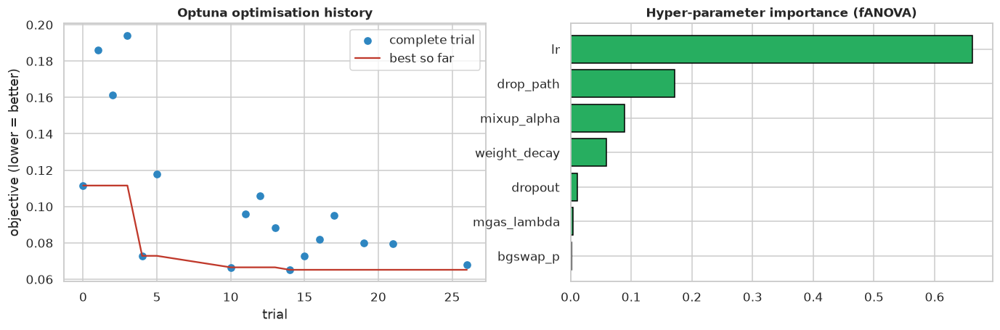

  ↳ figure saved: figures/fig12_optuna.png (+ .pdf)

BEST HYPER-PARAMETERS (used for the proposed model):
  lr            : 0.0001835
  weight_decay  : 0.001046
  dropout       : 0.4975
  drop_path     : 0.04001
  mixup_alpha   : 0.02145
  mgas_lambda   : 0.6541
  bgswap_p      : 0.7784


In [13]:
# ── 13 · Optuna ───────────────────────────────────────────────────────────────
BEST_HP_PATH = CKPT_DIR / "best_hp.json"
if C.RUN_OPTUNA:
    storage = f"sqlite:///{(CKPT_DIR / 'optuna.db').resolve()}"
    study = optuna.create_study(study_name="dfcvit4c_mgas_ccbs", direction="minimize", storage=storage,
                                load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=42),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=6))
    for t in study.trials:                                   # trials interrupted by a crash → mark failed
        if t.state == optuna.trial.TrialState.RUNNING:
            try: study.tell(t.number, state=optuna.trial.TrialState.FAIL)
            except Exception: pass

    def objective(trial):
        hp = dict(lr=trial.suggest_float("lr", 5e-5, 1e-3, log=True),
                  weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
                  dropout=trial.suggest_float("dropout", 0.1, 0.5),
                  drop_path=trial.suggest_float("drop_path", 0.0, 0.2),
                  mixup_alpha=trial.suggest_float("mixup_alpha", 0.0, 0.4),
                  mgas_lambda=trial.suggest_float("mgas_lambda", 0.0, 1.0),
                  bgswap_p=trial.suggest_float("bgswap_p", 0.0, 0.8))
        print(f"\n── Optuna trial {trial.number}: " + ", ".join(f"{k}={v:.3g}" for k, v in hp.items()))
        r = run_training(f"optuna/trial_{trial.number:03d}", build_dfcvit, hp, SPLIT, seed=42,
                         epochs=C.OPTUNA_EPOCHS, use_mgas=True, bgswap_p=hp["bgswap_p"],
                         trial=trial, eval_test=False, verbose=True)
        return r["best_objective"]

    def plateau_stop(study, trial):                          # early stopping for the whole search
        fin = [t for t in study.trials if t.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)]
        if len(fin) >= C.OPTUNA_MIN_TRIALS and trial.number - study.best_trial.number >= C.OPTUNA_PATIENCE:
            print(f"Optuna early stop: no improvement for {C.OPTUNA_PATIENCE} trials "
                  f"(best = trial {study.best_trial.number}, {study.best_value:.4f})")
            study.stop()

    done = [t for t in study.trials if t.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)]
    n_left = max(0, C.OPTUNA_TRIALS - len(done))
    if done and len(done) >= C.OPTUNA_MIN_TRIALS and done[-1].number - study.best_trial.number >= C.OPTUNA_PATIENCE:
        n_left = 0                                           # search already stopped early on a previous run
    print(f"Optuna: {len(done)} finished trials in storage, running {n_left} more …")
    if n_left:
        study.optimize(objective, n_trials=n_left, gc_after_trial=True, callbacks=[plateau_stop])
    BEST_HP = {**C.DEFAULT_HP, **study.best_params}
    save_json(BEST_HP, BEST_HP_PATH)

    tdf = study.trials_dataframe(attrs=("number", "value", "state", "params"))
    display(tdf.sort_values("value").head(10))
    save_table(tdf, "tab02_optuna_trials", "Optuna trials")
    comp = tdf[tdf.state == "COMPLETE"].sort_values("number")
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
    ax[0].scatter(comp.number, comp.value, color="#2E86C1", label="complete trial")
    ax[0].plot(comp.number, comp.value.cummin(), color="#C0392B", label="best so far")
    ax[0].set_xlabel("trial"); ax[0].set_ylabel("objective (lower = better)"); ax[0].legend()
    ax[0].set_title("Optuna optimisation history")
    try:
        imp = optuna.importance.get_param_importances(study)
        ax[1].barh(list(imp)[::-1], list(imp.values())[::-1], color="#27AE60", edgecolor="black")
        ax[1].set_title("Hyper-parameter importance (fANOVA)")
    except Exception as e:
        ax[1].text(0.5, 0.5, f"importance unavailable:\n{e}", ha="center", va="center"); ax[1].axis("off")
    save_fig(fig, "fig12_optuna")
elif BEST_HP_PATH.exists():
    BEST_HP = load_json(BEST_HP_PATH)
else:
    BEST_HP = dict(C.DEFAULT_HP)
print("\nBEST HYPER-PARAMETERS (used for the proposed model):")
for k, v in BEST_HP.items(): print(f"  {k:<14}: {v:.4g}")

## 14 · Train the proposed model (DFCViT-4C + MGAS + CCBS) with 3 seeds → test once → save final `.pt`


════ Proposed model | seed 42 ════
✓ [proposed/seed42] loaded from checkpoint (best epoch 32, val F1 1.0000, test acc 0.9955)

════ Proposed model | seed 123 ════
✓ [proposed/seed123] loaded from checkpoint (best epoch 28, val F1 1.0000, test acc 0.9910)

════ Proposed model | seed 2024 ════
✓ [proposed/seed2024] loaded from checkpoint (best epoch 45, val F1 1.0000, test acc 0.9925)


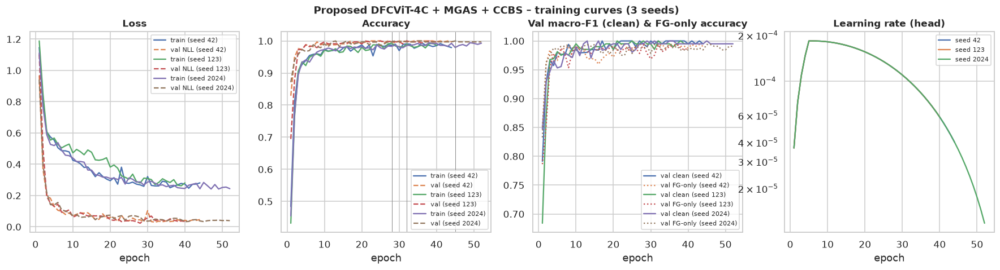

  ↳ figure saved: figures/fig13_proposed_training_curves.png (+ .pdf)


,seed,best epoch,acc,f1,fg_acc,fg_f1,bg_acc,SRI,FSR
0,42,32,0.995516,0.996231,0.989181,0.985647,0.261206,0.015034,0.993789
1,123,28,0.991031,0.987101,0.98609,0.981476,0.250386,0.000522,0.99532
2,2024,45,0.992526,0.991303,0.990726,0.987053,0.236476,-0.01822,0.998442
3,mean ± std,,0.9930 ± 0.0023,0.9915 ± 0.0046,0.9887 ± 0.0024,0.9847 ± 0.0029,0.2494 ± 0.0124,-0.0009 ± 0.0167,0.9959 ± 0.0024


  ↳ table saved: tables/tab03_proposed_seeds.csv

Classification report – TEST (seed 42):
              precision    recall  f1-score   support

         Bad     1.0000    1.0000    1.0000        60
      Defect     1.0000    0.9933    0.9967       150
    Immature     0.9861    1.0000    0.9930       142
      Mature     0.9968    0.9937    0.9953       317

    accuracy                         0.9955       669
   macro avg     0.9957    0.9968    0.9962       669
weighted avg     0.9956    0.9955    0.9955       669



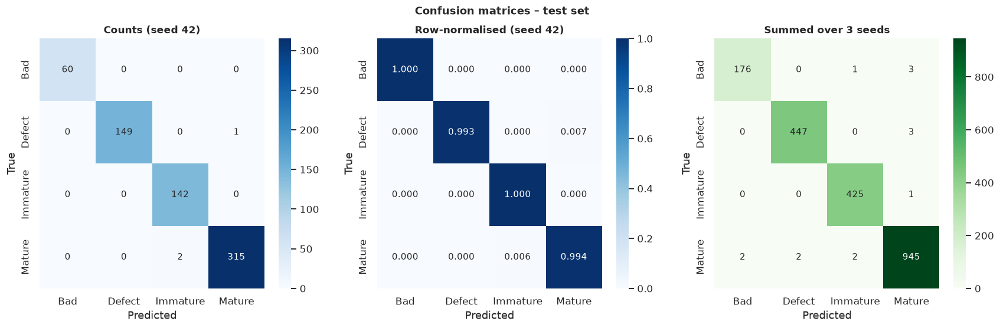

  ↳ figure saved: figures/fig14_confusion_matrices.png (+ .pdf)


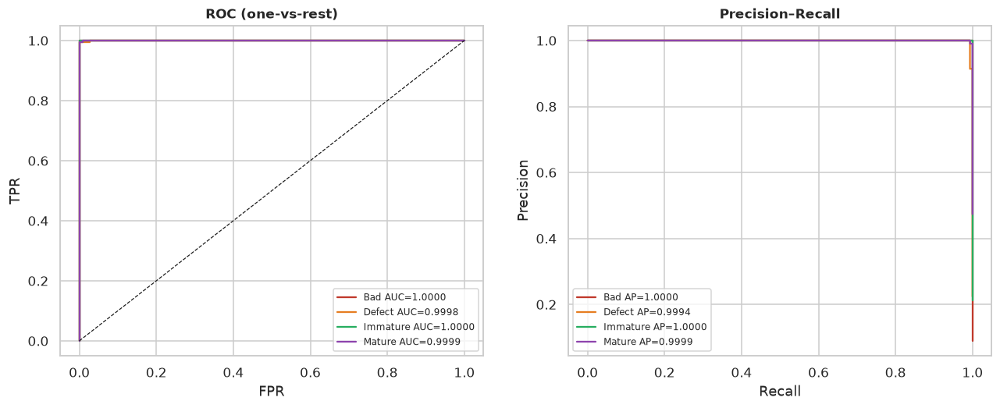

  ↳ figure saved: figures/fig15_roc_pr.png (+ .pdf)


/home/aiub/.venv/lib/python3.14/site-packages/torch/jit/_trace.py:1000: FutureWarning: `torch.jit.trace` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/aiub/.venv/lib/python3.14/site-packages/torch/jit/_trace.py:1139: FutureWarning: `torch.jit.trace_method` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


TorchScript export OK (max |Δ| vs eager = 0.00e+00)

Final model saved → /home/aiub/Dragon/dragon_q1_outputs/models/DFCViT4C_MGAS_CCBS_final.pt  (12.3 MB)


In [14]:
# ── 14 · Proposed model ───────────────────────────────────────────────────────
PROPOSED = []
for sd in C.SEEDS:
    print(f"\n════ Proposed model | seed {sd} ════")
    PROPOSED.append(run_training(f"proposed/seed{sd}", build_dfcvit, BEST_HP, SPLIT, sd, C.EPOCHS,
                                 use_mgas=True, bgswap_p=BEST_HP["bgswap_p"]))

plot_history(PROPOSED, "Proposed DFCViT-4C + MGAS + CCBS – training curves (3 seeds)", "fig13_proposed_training_curves")

_aud = [audit(r) for r in PROPOSED]
prop_tab = pd.DataFrame([{"seed": r["seed"], "best epoch": r["best_epoch"], **a} for r, a in zip(PROPOSED, _aud)]).astype(object)
prop_tab.loc[len(prop_tab)] = ["mean ± std", "", *[fmt_ms(pd.DataFrame(_aud)[c]) for c in ("acc", "f1", "fg_acc", "fg_f1", "bg_acc", "SRI", "FSR")]]
display(prop_tab)
save_table(prop_tab, "tab03_proposed_seeds", "Proposed model, test set, 3 seeds")

# Detailed report on the pre-declared FIRST seed (not the best seed → no cherry-picking)
R42 = PROPOSED[0]
S0 = C.SEEDS[0]
y, p, P = (np.array(R42["test"]["clean"][k]) for k in ("labels", "preds", "probs"))
print(f"\nClassification report – TEST (seed {S0}):")
print(classification_report(y, p, target_names=C.CLASSES, digits=4))
cm = confusion_matrix(y, p, labels=range(K))
cm_all = sum(confusion_matrix(np.array(r["test"]["clean"]["labels"]), np.array(r["test"]["clean"]["preds"]), labels=range(K)) for r in PROPOSED)
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], xticklabels=C.CLASSES, yticklabels=C.CLASSES)
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".3f", cmap="Blues", ax=ax[1], xticklabels=C.CLASSES, yticklabels=C.CLASSES, vmin=0, vmax=1)
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Greens", ax=ax[2], xticklabels=C.CLASSES, yticklabels=C.CLASSES)
for a, t in zip(ax, (f"Counts (seed {S0})", f"Row-normalised (seed {S0})", f"Summed over {len(PROPOSED)} seeds")):
    a.set_title(t); a.set_xlabel("Predicted"); a.set_ylabel("True")
fig.suptitle("Confusion matrices – test set", fontweight="bold")
save_fig(fig, "fig14_confusion_matrices")

yb = label_binarize(y, classes=range(K))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for ci, cls in enumerate(C.CLASSES):
    fpr, tpr, _ = roc_curve(yb[:, ci], P[:, ci]); ax[0].plot(fpr, tpr, color=CLASS_COLORS[ci], label=f"{cls} AUC={auc(fpr, tpr):.4f}")
    pr, rc, _ = precision_recall_curve(yb[:, ci], P[:, ci]); ax[1].plot(rc, pr, color=CLASS_COLORS[ci], label=f"{cls} AP={average_precision_score(yb[:, ci], P[:, ci]):.4f}")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("ROC (one-vs-rest)")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision–Recall")
for a in ax: a.legend(fontsize=8)
save_fig(fig, "fig15_roc_pr")

# ── Save the FINAL model as .pt (state_dict + everything needed for inference) ──
FINAL_PT = MODEL_DIR / "DFCViT4C_MGAS_CCBS_final.pt"
FINAL_TS = MODEL_DIR / "DFCViT4C_MGAS_CCBS_final_torchscript.pt"
_final = build_dfcvit(BEST_HP, pretrained=False).to(DEVICE, memory_format=torch.channels_last)
_final.load_state_dict(torch.load(CKPT_DIR / R42["run"] / "best.pt", map_location=DEVICE, weights_only=True), strict=True)
_final.eval()
atomic_torch_save(dict(model_state_dict=_final.state_dict(), architecture="DFCViT4C",
                       arch_kwargs=dict(num_classes=K, backbone=C.BACKBONE, embed_dim=C.EMBED_DIM, heads=C.NUM_HEADS,
                                        depth=C.DEPTH, dropout=BEST_HP["dropout"], drop_path=BEST_HP["drop_path"],
                                        img_size=C.IMG_SIZE, use_cbam=True, use_transformer=True),
                       classes=C.CLASSES, img_size=C.IMG_SIZE, mean=MEAN, std=STD, hyperparameters=BEST_HP,
                       test_metrics=audit(R42), torch_version=torch.__version__), FINAL_PT)
try:
    with torch.no_grad():
        _ts = torch.jit.trace(_final, torch.randn(2, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE), check_trace=False)
    _ts.save(str(FINAL_TS))
    with torch.no_grad():
        _d = (_ts(torch.ones(2, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE)) - _final(torch.ones(2, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE))).abs().max().item()
    if _d < 1e-3:
        print(f"TorchScript export OK (max |Δ| vs eager = {_d:.2e})")
    else:
        FINAL_TS.unlink(missing_ok=True); print(f"⚠ TorchScript output differs (|Δ|={_d:.2e}) – TorchScript file removed; use the state-dict .pt")
except Exception as e:
    print(f"⚠ TorchScript export skipped: {e}")
del _final; gc.collect()
print(f"\nFinal model saved → {FINAL_PT}  ({FINAL_PT.stat().st_size / 1e6:.1f} MB)")

## 15 · Baselines — same engine, LR chosen on validation, 3 seeds, full shortcut audit
Every baseline gets the **same** augmentation, sampler, loss, MixUp, schedule, early stopping and checkpoint selection as the proposed model.
Its LR is picked from `BASELINE_LR_GRID` with the same validation objective used by Optuna. A subset is also trained **with CCBS** to test
whether our augmentation alone explains the gain (fairness check).


════ Baseline ResNet-50 (resnet50) ════
  LR 0.0001: val objective 0.4818
  LR 0.0003: val objective 0.2420
  → selected LR 0.0003
✓ [baselines/ResNet-50/seed42] loaded from checkpoint (best epoch 50, val F1 1.0000, test acc 0.9925)
✓ [baselines/ResNet-50/seed123] loaded from checkpoint (best epoch 53, val F1 1.0000, test acc 0.9970)
✓ [baselines/ResNet-50/seed2024] loaded from checkpoint (best epoch 40, val F1 1.0000, test acc 0.9940)
✓ [baselines_ccbs/ResNet-50/seed42] loaded from checkpoint (best epoch 37, val F1 1.0000, test acc 0.9925)
✓ [baselines_ccbs/ResNet-50/seed123] loaded from checkpoint (best epoch 44, val F1 1.0000, test acc 0.9955)
✓ [baselines_ccbs/ResNet-50/seed2024] loaded from checkpoint (best epoch 53, val F1 1.0000, test acc 0.9940)

════ Baseline EfficientNet-B0 (efficientnet_b0) ════
  LR 0.0001: val objective 0.3036
  LR 0.0003: val objective 0.2192
  → selected LR 0.0003
✓ [baselines/EfficientNet-B0/seed42] loaded from checkpoint (best epoch 16, val F1 0.9975,

,Model,Params (M),Acc,Acc std,Macro-F1,Macro-F1 std,FG-only Acc,FG-only Acc std,BG-only Acc,BG-only Acc std,SRI ↓,SRI ↓ std
7,DeiT-Tiny + CCBS,5.5252,0.9960,0.0009,0.9956,0.0008,0.9954,0.0015,0.2561,0.0311,0.0081,0.0417
0,DFCViT-4C + MGAS + CCBS (ours),3.0123,0.9930,0.0023,0.9915,0.0046,0.9887,0.0024,0.2494,0.0124,-0.0009,0.0167
2,ResNet-50 + CCBS,23.5162,0.9940,0.0015,0.9938,0.0024,0.9871,0.0018,0.2427,0.0015,-0.0099,0.0021
4,EfficientNet-B0 + CCBS,4.0127,0.9900,0.0009,0.9844,0.0012,0.9758,0.0054,0.2566,0.0187,0.0089,0.0254
5,ConvNeXt-Tiny,27.8232,0.9985,0.0000,0.9977,0.0010,0.9624,0.0117,0.5899,0.1505,0.4541,0.2011
6,DeiT-Tiny,5.5252,0.9985,0.0000,0.9988,0.0000,0.9578,0.0133,0.6486,0.1540,0.5326,0.2058
1,ResNet-50,23.5162,0.9945,0.0023,0.9907,0.0036,0.9526,0.0193,0.7007,0.0386,0.6055,0.0519
9,VGG16,134.2769,0.9975,0.0017,0.9971,0.0028,0.9397,0.0147,0.6316,0.1710,0.5106,0.2285
3,EfficientNet-B0,4.0127,0.9935,0.0023,0.9909,0.0020,0.8954,0.0300,0.5183,0.0778,0.3607,0.1045
8,DenseNet201,18.1006,0.9985,0.0000,0.9977,0.0010,0.6430,0.0528,0.8691,0.0518,0.8272,0.0692


  ↳ table saved: tables/tab04_model_comparison.csv


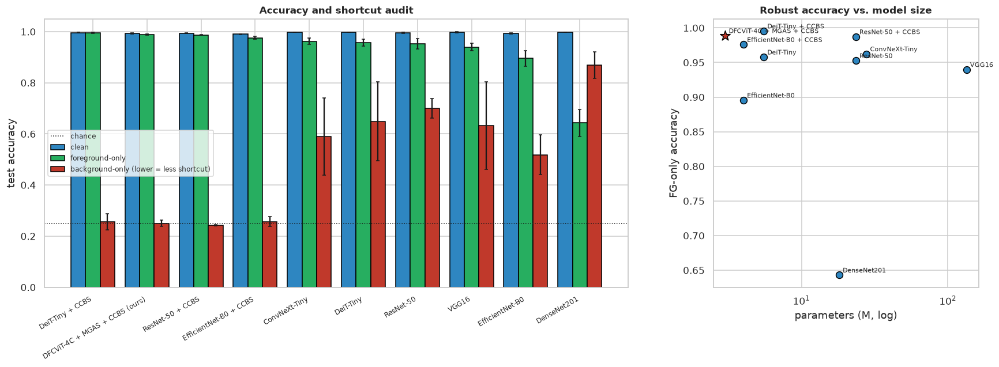

  ↳ figure saved: figures/fig16_model_comparison.png (+ .pdf)


In [15]:
# ── 15 · Baselines ────────────────────────────────────────────────────────────
BASE_HP = dict(weight_decay=C.DEFAULT_HP["weight_decay"], dropout=0.0, drop_path=0.0,
               mixup_alpha=BEST_HP["mixup_alpha"], mgas_lambda=0.0, bgswap_p=0.0)
BASELINE_RESULTS = {}      # name -> list of seed results
if C.RUN_BASELINES:
    for name, tid in C.BASELINES.items():
        print(f"\n════ Baseline {name} ({tid}) ════")
        sel = []
        for lr in C.BASELINE_LR_GRID:
            r = run_training(f"baselines_lrsel/{name}_lr{lr:g}", build_timm(tid), {**BASE_HP, "lr": lr}, SPLIT, 42,
                             C.OPTUNA_EPOCHS, eval_test=False, verbose=False)
            sel.append((r["best_objective"], lr)); print(f"  LR {lr:g}: val objective {r['best_objective']:.4f}")
        lr_best = min(sel)[1]; print(f"  → selected LR {lr_best:g}")
        BASELINE_RESULTS[name] = [run_training(f"baselines/{name}/seed{sd}", build_timm(tid), {**BASE_HP, "lr": lr_best},
                                               SPLIT, sd, C.EPOCHS) for sd in C.SEEDS]
        if name in C.BGSWAP_BASELINES:
            p_sw = BEST_HP["bgswap_p"] if BEST_HP["bgswap_p"] > 0.05 else C.DEFAULT_HP["bgswap_p"]
            BASELINE_RESULTS[f"{name} + CCBS"] = [run_training(f"baselines_ccbs/{name}/seed{sd}", build_timm(tid),
                                                               {**BASE_HP, "lr": lr_best, "bgswap_p": p_sw}, SPLIT, sd,
                                                               C.EPOCHS, bgswap_p=p_sw) for sd in C.SEEDS]

def summarize(name, results):
    a = [audit(r) for r in results]
    row = {"Model": name, "Params (M)": results[0]["params"] / 1e6}
    for k, lab in (("acc", "Acc"), ("f1", "Macro-F1"), ("fg_acc", "FG-only Acc"), ("bg_acc", "BG-only Acc"), ("SRI", "SRI ↓")):
        v = np.array([x[k] for x in a]); row[lab] = v.mean(); row[lab + " std"] = v.std(ddof=1) if len(v) > 1 else 0.0
    return row

ALL_MODELS = {"DFCViT-4C + MGAS + CCBS (ours)": PROPOSED, **BASELINE_RESULTS}
cmp_df = pd.DataFrame([summarize(n, r) for n, r in ALL_MODELS.items()]).sort_values("FG-only Acc", ascending=False)
display(cmp_df.round(4))
save_table(cmp_df.round(4), "tab04_model_comparison", "Comparison on the test set (mean and std over 3 seeds)")

fig, ax = plt.subplots(1, 2, figsize=(19, 5.5), gridspec_kw=dict(width_ratios=[2.2, 1]))
x = np.arange(len(cmp_df)); w = 0.27
for i, (col, lab, c) in enumerate((("Acc", "clean", "#2E86C1"), ("FG-only Acc", "foreground-only", "#27AE60"),
                                    ("BG-only Acc", "background-only (lower = less shortcut)", "#C0392B"))):
    ax[0].bar(x + (i - 1) * w, cmp_df[col], w, yerr=cmp_df[col + " std"], capsize=2, label=lab, color=c, edgecolor="black")
ax[0].axhline(1 / K, color="k", ls=":", lw=1, label="chance")
ax[0].set_xticks(x); ax[0].set_xticklabels(cmp_df.Model, rotation=30, ha="right", fontsize=8)
ax[0].set_ylabel("test accuracy"); ax[0].set_ylim(0, 1.05); ax[0].legend(fontsize=8); ax[0].set_title("Accuracy and shortcut audit")
for _, r in cmp_df.iterrows():
    ours = "ours" in r.Model
    ax[1].scatter(r["Params (M)"], r["FG-only Acc"], s=140 if ours else 60, marker="*" if ours else "o",
                  color="#C0392B" if ours else "#2E86C1", edgecolor="black", zorder=3)
    ax[1].annotate(r.Model.replace(" (ours)", ""), (r["Params (M)"], r["FG-only Acc"]), fontsize=7,
                   xytext=(4, 3), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].set_xlabel("parameters (M, log)"); ax[1].set_ylabel("FG-only accuracy")
ax[1].set_title("Robust accuracy vs. model size")
save_fig(fig, "fig16_model_comparison")

## 16 · Ablation study (3 seeds each) — every component measured on clean **and** shortcut metrics


════ A1 Backbone only ════
✓ [ablation/A1/seed42] loaded from checkpoint (best epoch 50, val F1 1.0000, test acc 0.9985)
✓ [ablation/A1/seed123] loaded from checkpoint (best epoch 25, val F1 1.0000, test acc 0.9985)
✓ [ablation/A1/seed2024] loaded from checkpoint (best epoch 8, val F1 1.0000, test acc 0.9955)

════ A2 + CBAM ════
✓ [ablation/A2/seed42] loaded from checkpoint (best epoch 16, val F1 1.0000, test acc 0.9955)
✓ [ablation/A2/seed123] loaded from checkpoint (best epoch 25, val F1 0.9950, test acc 0.9970)
✓ [ablation/A2/seed2024] loaded from checkpoint (best epoch 18, val F1 1.0000, test acc 0.9970)

════ A3 + Transformer ════
✓ [ablation/A3/seed42] loaded from checkpoint (best epoch 10, val F1 1.0000, test acc 0.9955)
✓ [ablation/A3/seed123] loaded from checkpoint (best epoch 28, val F1 1.0000, test acc 0.9985)
✓ [ablation/A3/seed2024] loaded from checkpoint (best epoch 11, val F1 1.0000, test acc 0.9985)

════ A4 DFCViT-4C (CBAM+Trans) ════
✓ [ablation/A4/seed42] loaded fr

,Model,Params (M),Acc,Acc std,Macro-F1,Macro-F1 std,FG-only Acc,FG-only Acc std,BG-only Acc,BG-only Acc std,SRI ↓,SRI ↓ std
0,A1 Backbone only,1.9281,0.9975,0.0017,0.9974,0.0024,0.7048,0.0321,0.5255,0.0654,0.3687,0.0883
1,A2 + CBAM,1.9446,0.9965,0.0009,0.9950,0.0023,0.7321,0.0483,0.5265,0.1208,0.3704,0.1615
2,A3 + Transformer,2.9958,0.9975,0.0017,0.9966,0.0038,0.8568,0.0580,0.5544,0.1213,0.4074,0.1631
3,A4 DFCViT-4C (CBAM+Trans),3.0123,0.9970,0.0040,0.9962,0.0056,0.7372,0.0467,0.5750,0.1515,0.4343,0.2011
4,A5 A4 + CCBS,3.0123,0.9940,0.0040,0.9922,0.0057,0.9876,0.0041,0.2396,0.0101,-0.0140,0.0136
5,A6 A4 + MGAS,3.0123,0.9960,0.0017,0.9957,0.0022,0.7950,0.0347,0.4261,0.0240,0.2358,0.0315
6,A7 Proposed (A4+MGAS+CCBS),3.0123,0.9930,0.0023,0.9915,0.0046,0.9887,0.0024,0.2494,0.0124,-0.0009,0.0167


  ↳ table saved: tables/tab05_ablation.csv


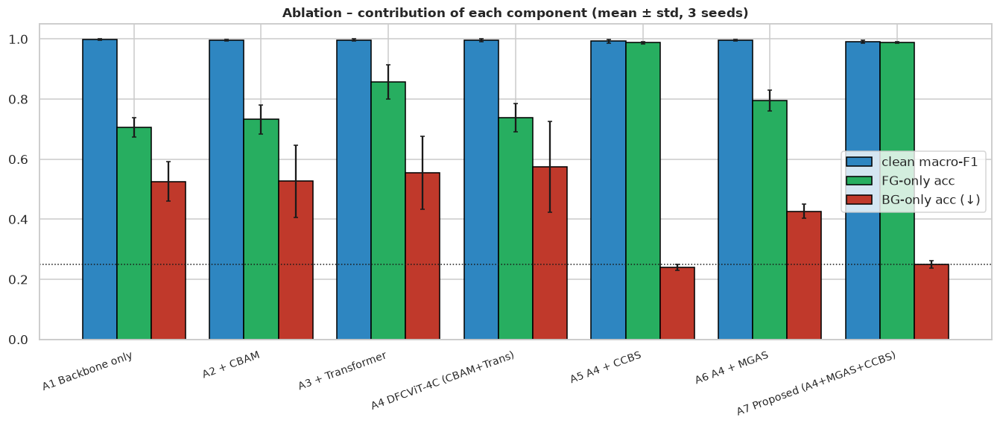

  ↳ figure saved: figures/fig17_ablation.png (+ .pdf)


In [16]:
# ── 16 · Ablation ─────────────────────────────────────────────────────────────
lam_abl = BEST_HP["mgas_lambda"] if BEST_HP["mgas_lambda"] >= 0.05 else C.DEFAULT_HP["mgas_lambda"]
p_abl = BEST_HP["bgswap_p"] if BEST_HP["bgswap_p"] >= 0.05 else C.DEFAULT_HP["bgswap_p"]
ABLATIONS = {   # name: (use_cbam, use_transformer, mgas_lambda, bgswap_p, run prefix)
    "A1 Backbone only":            (False, False, 0.0, 0.0, "ablation/A1"),
    "A2 + CBAM":                   (True, False, 0.0, 0.0, "ablation/A2"),
    "A3 + Transformer":            (False, True, 0.0, 0.0, "ablation/A3"),
    "A4 DFCViT-4C (CBAM+Trans)":   (True, True, 0.0, 0.0, "ablation/A4"),
    "A5 A4 + CCBS":                (True, True, 0.0, p_abl, "ablation/A5"),
    "A6 A4 + MGAS":                (True, True, lam_abl, 0.0, "ablation/A6"),
    "A7 Proposed (A4+MGAS+CCBS)":  (True, True, BEST_HP["mgas_lambda"], BEST_HP["bgswap_p"], "proposed"),
}
ABL_RESULTS = {}
if C.RUN_ABLATION:
    for name, (cb, tr, lam, psw, pref) in ABLATIONS.items():
        print(f"\n════ {name} ════")
        hp = {**BEST_HP, "mgas_lambda": lam, "bgswap_p": psw}
        bf = (lambda h, pretrained=None, cb=cb, tr=tr: build_dfcvit(h, cb, tr, pretrained))
        ABL_RESULTS[name] = [run_training(f"{pref}/seed{sd}", bf, hp, SPLIT, sd, C.EPOCHS,
                                          use_mgas=(lam > 0 and cb), bgswap_p=psw) for sd in C.SEEDS]
    abl_df = pd.DataFrame([summarize(n, r) for n, r in ABL_RESULTS.items()])
    display(abl_df.round(4))
    save_table(abl_df.round(4), "tab05_ablation", "Ablation study (mean and std over 3 seeds)")
    fig, ax = plt.subplots(figsize=(15, 5))
    x = np.arange(len(abl_df)); w = 0.27
    for i, (col, lab, c) in enumerate((("Macro-F1", "clean macro-F1", "#2E86C1"), ("FG-only Acc", "FG-only acc", "#27AE60"),
                                        ("BG-only Acc", "BG-only acc (↓)", "#C0392B"))):
        ax.bar(x + (i - 1) * w, abl_df[col], w, yerr=abl_df[col + " std"], capsize=2, label=lab, color=c, edgecolor="black")
    ax.axhline(1 / K, color="k", ls=":", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(abl_df.Model, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("Ablation – contribution of each component (mean ± std, 3 seeds)")
    save_fig(fig, "fig17_ablation")

## 17 · 5-fold group-stratified cross-validation (proposed model) with an **inner validation split** per fold


════ Fold 1/5: train 2338 | val 334 | test 669 ════
✓ [kfold/fold1] loaded from checkpoint (best epoch 34, val F1 0.9951, test acc 0.9985)

════ Fold 2/5: train 2339 | val 334 | test 668 ════
✓ [kfold/fold2] loaded from checkpoint (best epoch 27, val F1 1.0000, test acc 0.9880)

════ Fold 3/5: train 2338 | val 335 | test 668 ════
✓ [kfold/fold3] loaded from checkpoint (best epoch 43, val F1 1.0000, test acc 0.9940)

════ Fold 4/5: train 2338 | val 335 | test 668 ════
✓ [kfold/fold4] loaded from checkpoint (best epoch 46, val F1 0.9904, test acc 0.9895)

════ Fold 5/5: train 2339 | val 334 | test 668 ════
✓ [kfold/fold5] loaded from checkpoint (best epoch 33, val F1 1.0000, test acc 0.9940)


,fold,acc,f1,fg_acc,fg_f1,bg_acc,SRI,FSR
0,1,0.998505,0.99877,0.97527,0.969873,0.230294,-0.026329,0.97678
1,2,0.988024,0.982376,0.98748,0.983855,0.233177,-0.022812,1.0
2,3,0.994012,0.989229,0.989231,0.983822,0.238462,-0.015448,0.992284
3,4,0.989521,0.987717,0.992224,0.990308,0.242613,-0.009995,1.003145
4,5,0.994012,0.9909,0.989097,0.984379,0.258567,0.011518,0.995298
5,mean ± std,0.9928 ± 0.0042,0.9898 ± 0.0059,0.9867 ± 0.0066,0.9824 ± 0.0075,0.2406 ± 0.0111,-0.0126 ± 0.0149,0.9935 ± 0.0102


  ↳ table saved: tables/tab06_kfold.csv


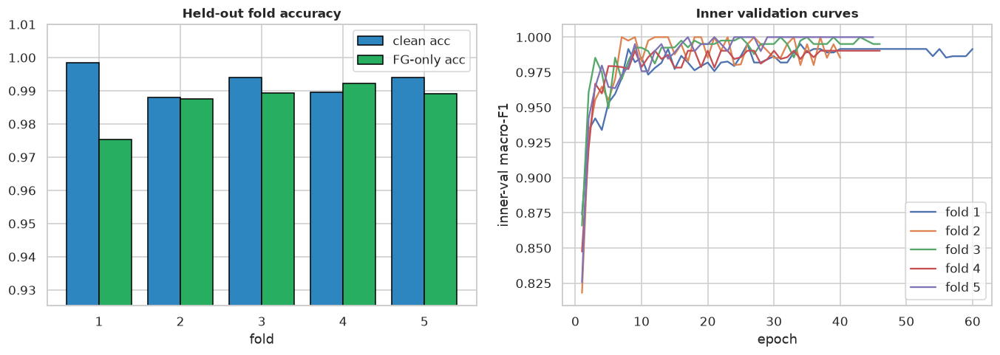

  ↳ figure saved: figures/fig18_kfold.png (+ .pdf)


In [17]:
# ── 17 · K-fold CV ────────────────────────────────────────────────────────────
KFOLD_RESULTS = []
if C.RUN_KFOLD:
    sgkf = StratifiedGroupKFold(n_splits=C.KFOLDS, shuffle=True, random_state=42)
    for f, (trv, te) in enumerate(sgkf.split(np.zeros(N), LABELS, GROUPS), 1):
        tr, va = group_split(trv, C.VAL_FRAC / (1 - 1 / C.KFOLDS), seed=42 + f)
        fold_split = {"train": tr, "val": va, "test": np.sort(te)}
        print(f"\n════ Fold {f}/{C.KFOLDS}: train {len(tr)} | val {len(va)} | test {len(te)} ════")
        KFOLD_RESULTS.append(run_training(f"kfold/fold{f}", build_dfcvit, BEST_HP, fold_split, 42, C.EPOCHS,
                                          use_mgas=True, bgswap_p=BEST_HP["bgswap_p"]))
    kf_df = pd.DataFrame([{"fold": i + 1, **audit(r)} for i, r in enumerate(KFOLD_RESULTS)])
    kf_df = kf_df.astype(object)
    kf_df.loc[len(kf_df)] = ["mean ± std", *[fmt_ms(kf_df[c][:C.KFOLDS]) for c in kf_df.columns[1:]]]
    display(kf_df)
    save_table(kf_df, "tab06_kfold", "5-fold group-stratified cross-validation")
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    vals = pd.DataFrame([audit(r) for r in KFOLD_RESULTS])
    ax[0].bar(np.arange(1, C.KFOLDS + 1) - 0.2, vals.acc, 0.4, label="clean acc", color="#2E86C1", edgecolor="black")
    ax[0].bar(np.arange(1, C.KFOLDS + 1) + 0.2, vals.fg_acc, 0.4, label="FG-only acc", color="#27AE60", edgecolor="black")
    ax[0].set_ylim(min(vals.fg_acc.min(), vals.acc.min()) - 0.05, 1.01); ax[0].set_xlabel("fold"); ax[0].legend()
    ax[0].set_title("Held-out fold accuracy")
    for i, r in enumerate(KFOLD_RESULTS):
        ax[1].plot(np.arange(1, len(r["hist"]["va_f1"]) + 1), r["hist"]["va_f1"], label=f"fold {i + 1}")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("inner-val macro-F1"); ax[1].legend(); ax[1].set_title("Inner validation curves")
    save_fig(fig, "fig18_kfold")

## 18 · Statistical tests — exact paired McNemar (Holm-corrected) + bootstrap 95 % CIs
Paired on the **same test images**, first seed. Clean test and foreground-only test are tested separately.

,Model,Macro-F1,Macro-F1 95% CI,FG-only Acc,FG-only Acc 95% CI,clean: ours✓/base✗,clean: ours✗/base✓,clean: p,fg: ours✓/base✗,fg: ours✗/base✓,fg: p,clean: p (Holm),fg: p (Holm)
0,DFCViT-4C + MGAS + CCBS (ours),0.996231,"[0.9915, 1.0000]",0.989181,"[0.9799, 0.9969]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ResNet-50,0.987577,"[0.9754, 0.9976]",0.933539,"[0.9134, 0.9521]",2.0,0.0,0.50,41.0,5.0,4.405936e-08,1.0,2.643562e-07
2,ResNet-50 + CCBS,0.991336,"[0.9820, 0.9987]",0.986090,"[0.9768, 0.9938]",2.0,0.0,0.50,5.0,3.0,7.265625e-01,1.0,8.671875e-01
3,EfficientNet-B0,0.992910,"[0.9835, 1.0000]",0.862442,"[0.8346, 0.8872]",2.0,2.0,1.00,84.0,2.0,9.672843e-23,1.0,7.738275e-22
4,EfficientNet-B0 + CCBS,0.985705,"[0.9728, 0.9960]",0.981453,"[0.9706, 0.9907]",3.0,0.0,0.25,10.0,5.0,3.017578e-01,1.0,8.671875e-01
5,ConvNeXt-Tiny,0.998770,"[0.9961, 1.0000]",0.970634,"[0.9567, 0.9830]",0.0,2.0,0.50,15.0,3.0,7.537842e-03,1.0,3.015137e-02
6,DeiT-Tiny,0.998770,"[0.9961, 1.0000]",0.945904,"[0.9274, 0.9629]",0.0,2.0,0.50,31.0,3.0,7.660128e-07,1.0,3.830064e-06
7,DeiT-Tiny + CCBS,0.996231,"[0.9915, 1.0000]",0.995363,"[0.9892, 1.0000]",0.0,0.0,1.00,2.0,6.0,2.890625e-01,1.0,8.671875e-01
8,DenseNet201,0.998770,"[0.9961, 1.0000]",0.649150,"[0.6121, 0.6862]",0.0,2.0,0.50,222.0,2.0,1.869514e-63,1.0,1.682563e-62
9,VGG16,0.998770,"[0.9961, 1.0000]",0.922720,"[0.9011, 0.9413]",0.0,2.0,0.50,46.0,3.0,6.981082e-11,1.0,4.886758e-10


  ↳ table saved: tables/tab07_statistics.csv


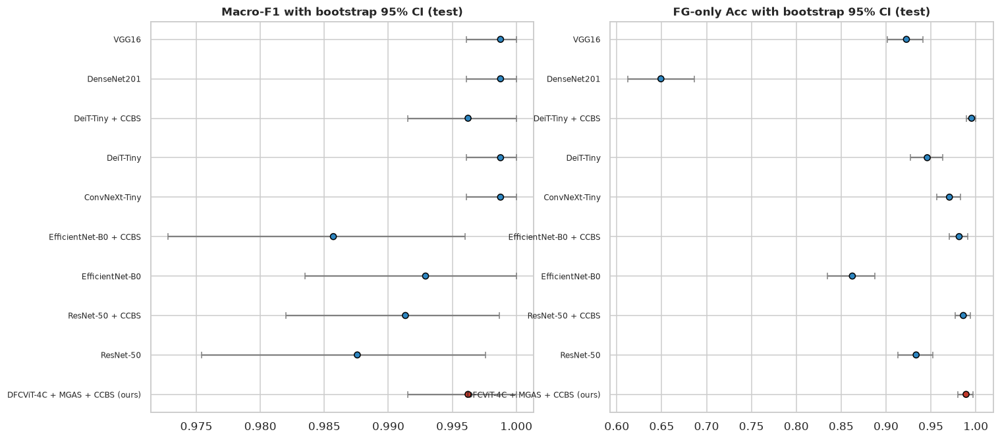

  ↳ figure saved: figures/fig19_bootstrap_ci.png (+ .pdf)


In [18]:
# ── 18 · Statistics ───────────────────────────────────────────────────────────
def mcnemar_exact(y, pa, pb):
    a, b = pa == y, pb == y
    n01, n10 = int((a & ~b).sum()), int((~a & b).sum())
    p = 1.0 if n01 + n10 == 0 else float(stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue)
    return n01, n10, p

def holm(pvals):
    p = np.asarray(pvals); order = np.argsort(p); adj = np.empty_like(p); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, min(1.0, (len(p) - rank) * p[i])); adj[i] = run
    return adj

def boot_ci(y, pred, fn, n=C.N_BOOT, seed=0):
    r = np.random.default_rng(seed); vals = []
    for _ in range(n):
        ix = r.integers(0, len(y), len(y)); vals.append(fn(y[ix], pred[ix]))
    return np.percentile(vals, [2.5, 97.5])

_mf1 = lambda a, b: f1_score(a, b, average="macro", zero_division=0)
ours = PROPOSED[0]["test"]
rows = []
for name, res in ALL_MODELS.items():
    t = res[0]["test"]
    row = {"Model": name}
    for view, fn, lab in (("clean", _mf1, "Macro-F1"), ("fg", accuracy_score, "FG-only Acc")):
        yv, pv = np.array(t[view]["labels"]), np.array(t[view]["preds"])
        lo, hi = boot_ci(yv, pv, fn)
        row[f"{lab}"] = fn(yv, pv); row[f"{lab} 95% CI"] = f"[{lo:.4f}, {hi:.4f}]"
        if "ours" not in name:
            n01, n10, p = mcnemar_exact(yv, np.array(ours[view]["preds"]), pv)
            row[f"{view}: ours✓/base✗"] = n01; row[f"{view}: ours✗/base✓"] = n10; row[f"{view}: p"] = p
    rows.append(row)
stat_df = pd.DataFrame(rows)
for view in ("clean", "fg"):
    if f"{view}: p" not in stat_df: continue
    m = stat_df[f"{view}: p"].notna()
    stat_df.loc[m, f"{view}: p (Holm)"] = holm(stat_df.loc[m, f"{view}: p"].values)
display(stat_df)
save_table(stat_df, "tab07_statistics", "Exact McNemar tests (Holm) and bootstrap confidence intervals")

fig, ax = plt.subplots(1, 2, figsize=(15, 0.5 * len(stat_df) + 2))
for a, lab in zip(ax, ("Macro-F1", "FG-only Acc")):
    ci = stat_df[f"{lab} 95% CI"].str.strip("[]").str.split(", ", expand=True).astype(float)
    yy = np.arange(len(stat_df))
    cols = ["#C0392B" if "ours" in n else "#2E86C1" for n in stat_df.Model]
    a.errorbar(stat_df[lab], yy, xerr=[stat_df[lab] - ci[0], ci[1] - stat_df[lab]], fmt="none", ecolor="gray", capsize=3)
    a.scatter(stat_df[lab], yy, color=cols, zorder=3, edgecolor="black")
    a.set_yticks(yy); a.set_yticklabels(stat_df.Model, fontsize=8); a.set_title(f"{lab} with bootstrap 95% CI (test)")
save_fig(fig, "fig19_bootstrap_ci")

## 19 · Explainability on **test** images — Grad-CAM (256-ch projection layer) + Integrated Gradients + quantitative Energy-in-Fruit Ratio
* **EFR** = fraction of Grad-CAM energy that falls inside the fruit mask (1.0 = all attention on the fruit). Reported with the mask area as the
  random-attention reference. Computed for every ablation variant (first seed) on all test images with a valid mask.
* Figure rows include misclassified test images of the proposed model (if any).

  A1 Backbone only                 EFR=0.3422  (random reference 0.3154)
  A2 + CBAM                        EFR=0.3406  (random reference 0.3154)


/home/aiub/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:1072: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:910.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  A3 + Transformer                 EFR=0.2163  (random reference 0.3154)
  A4 DFCViT-4C (CBAM+Trans)        EFR=0.3598  (random reference 0.3154)
  A5 A4 + CCBS                     EFR=0.5110  (random reference 0.3154)
  A6 A4 + MGAS                     EFR=0.3766  (random reference 0.3154)
  A7 Proposed (A4+MGAS+CCBS)       EFR=0.6445  (random reference 0.3154)


,Model,EFR (mean),EFR (median),mask area (random ref.),EFR / area
0,A1 Backbone only,0.3422,0.3117,0.3154,1.0852
1,A2 + CBAM,0.3406,0.2769,0.3154,1.0798
2,A3 + Transformer,0.2163,0.1292,0.3154,0.6860
3,A4 DFCViT-4C (CBAM+Trans),0.3598,0.3025,0.3154,1.1407
4,A5 A4 + CCBS,0.5110,0.5337,0.3154,1.6202
5,A6 A4 + MGAS,0.3766,0.3307,0.3154,1.1942
6,A7 Proposed (A4+MGAS+CCBS),0.6445,0.6867,0.3154,2.0436


  ↳ table saved: tables/tab08_energy_in_fruit.csv


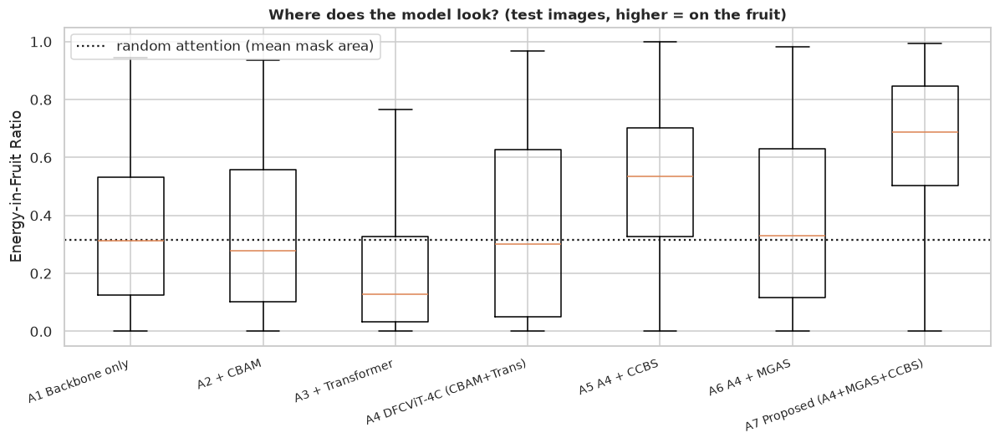

  ↳ figure saved: figures/fig20_energy_in_fruit.png (+ .pdf)


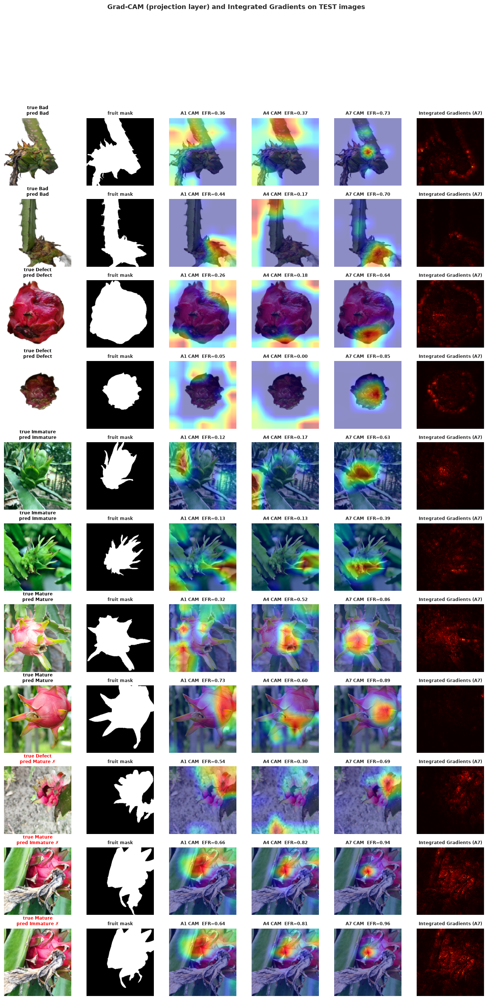

  ↳ figure saved: figures/fig21_gradcam_ig.png (+ .pdf)


In [19]:
# ── 19 · XAI ──────────────────────────────────────────────────────────────────
def load_run_model(run_name, build_fn, hp):
    m = build_fn(hp, pretrained=False).to(DEVICE, memory_format=torch.channels_last)
    m.load_state_dict(torch.load(CKPT_DIR / run_name / "best.pt", map_location=DEVICE, weights_only=True), strict=True)
    return m.eval()

def gradcam(model, x, target):
    store = {}
    def fwd(_, __, out):
        store["a"] = out
        out.register_hook(lambda g: store.__setitem__("g", g))
    h = model.proj.register_forward_hook(fwd)
    try:
        model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = model(x)
            logits.gather(1, target[:, None]).sum().backward()
        a, g = store["a"].detach().float(), store["g"].detach().float()
        cam = F.relu((g.mean((2, 3), keepdim=True) * a).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
        mn = cam.flatten(1).min(1)[0][:, None, None]; mx = cam.flatten(1).max(1)[0][:, None, None]
        cam = (cam - mn) / (mx - mn + 1e-8)
    finally:
        h.remove()
    return cam.cpu().numpy(), logits.detach().float().softmax(1).cpu().numpy()

def integrated_gradients(model, x1, target, steps=32):
    base = torch.zeros_like(x1)
    alphas = torch.linspace(0, 1, steps, device=DEVICE)[:, None, None, None]
    xs = (base + alphas * (x1 - base)).requires_grad_(True)
    with torch.enable_grad():
        out = model(xs)[:, target].sum()
        g, = torch.autograd.grad(out, xs)
    attr = ((x1 - base) * g.mean(0, keepdim=True))[0].abs().sum(0)
    attr = attr / (attr.max() + 1e-8)
    return attr.detach().cpu().numpy()

XAI = {}
if C.RUN_XAI and C.RUN_ABLATION:
    te = SPLIT["test"]; te_v = te[VALID[te]]
    xai_dl = GPULoader(te_v, batch_size=64)
    efr_rows = []
    for name, (cb, tr, lam, psw, pref) in ABLATIONS.items():
        bf = (lambda h, pretrained=None, cb=cb, tr=tr: build_dfcvit(h, cb, tr, pretrained))
        model = load_run_model(f"{pref}/seed{C.SEEDS[0]}", bf, {**BEST_HP, "mgas_lambda": lam, "bgswap_p": psw})
        cams, efr, area = [], [], []
        for x, y, mk, _ in xai_dl:
            cam, _ = gradcam(model, x, y)
            mb = (mk[:, 0].float().cpu().numpy() > 0.5).astype(np.float32)
            efr += list((cam * mb).sum((1, 2)) / (cam.sum((1, 2)) + 1e-8)); area += list(mb.mean((1, 2)))
            cams.append(cam.astype(np.float16))
        XAI[name] = dict(cams=np.concatenate(cams), efr=np.array(efr), area=np.array(area))
        efr_rows.append({"Model": name, "EFR (mean)": np.mean(efr), "EFR (median)": np.median(efr),
                         "mask area (random ref.)": np.mean(area), "EFR / area": np.mean(efr) / np.mean(area)})
        print(f"  {name:<32} EFR={np.mean(efr):.4f}  (random reference {np.mean(area):.4f})")
        del model; gc.collect()
    del xai_dl
    efr_df = pd.DataFrame(efr_rows); display(efr_df.round(4))
    save_table(efr_df.round(4), "tab08_energy_in_fruit", "Grad-CAM Energy-in-Fruit Ratio on test images")

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.boxplot([XAI[n]["efr"] for n in XAI], showfliers=False)
    ax.set_xticks(range(1, len(XAI) + 1)); ax.set_xticklabels(list(XAI), rotation=20, ha="right", fontsize=9)
    ax.axhline(np.mean(XAI[list(XAI)[0]]["area"]), color="k", ls=":", label="random attention (mean mask area)")
    ax.set_ylabel("Energy-in-Fruit Ratio"); ax.legend(); ax.set_title("Where does the model look? (test images, higher = on the fruit)")
    save_fig(fig, "fig20_energy_in_fruit")

    # Qualitative grid: 2 correct per class + up to 4 misclassified (proposed, first seed)
    tv_pos = {int(j): k for k, j in enumerate(te_v)}
    pr_clean = dict(zip(np.array(PROPOSED[0]["test"]["clean"]["idx"]).tolist(), PROPOSED[0]["test"]["clean"]["preds"]))
    wrong = [j for j in te_v if pr_clean[int(j)] != LABELS[j]][:4]
    pick = []
    for ci in range(K):
        pick += [j for j in te_v if LABELS[j] == ci and pr_clean[int(j)] == ci][:2]
    pick += wrong
    show_models = ["A1 Backbone only", "A4 DFCViT-4C (CBAM+Trans)", "A7 Proposed (A4+MGAS+CCBS)"]
    final_m = load_run_model(f"proposed/seed{C.SEEDS[0]}", build_dfcvit, BEST_HP)
    ncol = 3 + len(show_models)
    fig, axes = plt.subplots(len(pick), ncol, figsize=(2.6 * ncol, 2.6 * len(pick)))
    axes = np.atleast_2d(axes)
    for r, j in enumerate(pick):
        base_img = cv2.resize(IMGS[j], (C.IMG_SIZE, C.IMG_SIZE))
        axes[r, 0].imshow(base_img)
        axes[r, 0].set_title(f"true {C.CLASSES[LABELS[j]]}\npred {C.CLASSES[pr_clean[int(j)]]}" +
                             (" ✗" if pr_clean[int(j)] != LABELS[j] else ""), fontsize=8,
                             color="red" if pr_clean[int(j)] != LABELS[j] else "black")
        axes[r, 1].imshow(cv2.resize(MASKS[j], (C.IMG_SIZE, C.IMG_SIZE)), cmap="gray"); axes[r, 1].set_title("fruit mask", fontsize=8)
        for c_, n in enumerate(show_models):
            cam = XAI[n]["cams"][tv_pos[int(j)]].astype(np.float32)
            axes[r, 2 + c_].imshow(base_img); axes[r, 2 + c_].imshow(cam, cmap="jet", alpha=0.45)
            axes[r, 2 + c_].set_title(f"{n.split(' ')[0]} CAM  EFR={XAI[n]['efr'][tv_pos[int(j)]]:.2f}", fontsize=8)
        x1 = next(iter(GPULoader([j])))[0]
        ig = integrated_gradients(final_m, x1, int(LABELS[j]))
        axes[r, -1].imshow(ig, cmap="hot"); axes[r, -1].set_title("Integrated Gradients (A7)", fontsize=8)
        for a in axes[r]: a.axis("off")
    fig.suptitle("Grad-CAM (projection layer) and Integrated Gradients on TEST images", fontweight="bold")
    save_fig(fig, "fig21_gradcam_ig")
    del final_m; gc.collect()
else:
    print("XAI skipped (needs RUN_XAI and RUN_ABLATION).")

## 20 · Final summary (all numbers for the manuscript) + saved files

  FINAL SUMMARY – DFCViT-4C + MGAS + CCBS (4-class dragon fruit)
  Images used            : 3341  (after exact + near-duplicate cleaning)
  Split (group-aware)    : train 2338 | val 334 | test 669
  Mask method            : u2net-onnx | valid masks 3221/3341
  Proposed params        : 3.01 M
  Best hyper-parameters  : lr=0.000184, weight_decay=0.00105, dropout=0.498, drop_path=0.04, mixup_alpha=0.0215, mgas_lambda=0.654, bgswap_p=0.778

  Proposed model on TEST (mean ± std over seeds):
    Accuracy                      : 0.9930 ± 0.0023
    Macro-F1                      : 0.9915 ± 0.0046
    FG-only accuracy              : 0.9887 ± 0.0024
    BG-only accuracy (↓)          : 0.2494 ± 0.0124
    Shortcut Reliance Index (↓)   : -0.0009 ± 0.0167

  5-fold CV accuracy             : 0.9928 ± 0.0042
  5-fold CV FG-only accuracy     : 0.9867 ± 0.0066

  Model comparison (sorted by FG-only accuracy):


,Model,Params (M),Acc,Macro-F1,FG-only Acc,BG-only Acc,SRI ↓
7,DeiT-Tiny + CCBS,5.5252,0.9960,0.9956,0.9954,0.2561,0.0081
0,DFCViT-4C + MGAS + CCBS (ours),3.0123,0.9930,0.9915,0.9887,0.2494,-0.0009
2,ResNet-50 + CCBS,23.5162,0.9940,0.9938,0.9871,0.2427,-0.0099
4,EfficientNet-B0 + CCBS,4.0127,0.9900,0.9844,0.9758,0.2566,0.0089
5,ConvNeXt-Tiny,27.8232,0.9985,0.9977,0.9624,0.5899,0.4541
6,DeiT-Tiny,5.5252,0.9985,0.9988,0.9578,0.6486,0.5326
1,ResNet-50,23.5162,0.9945,0.9907,0.9526,0.7007,0.6055
9,VGG16,134.2769,0.9975,0.9971,0.9397,0.6316,0.5106
3,EfficientNet-B0,4.0127,0.9935,0.9909,0.8954,0.5183,0.3607
8,DenseNet201,18.1006,0.9985,0.9977,0.6430,0.8691,0.8272



  Ablation:


,Model,Acc,Macro-F1,FG-only Acc,BG-only Acc,SRI ↓
0,A1 Backbone only,0.9975,0.9974,0.7048,0.5255,0.3687
1,A2 + CBAM,0.9965,0.9950,0.7321,0.5265,0.3704
2,A3 + Transformer,0.9975,0.9966,0.8568,0.5544,0.4074
3,A4 DFCViT-4C (CBAM+Trans),0.9970,0.9962,0.7372,0.5750,0.4343
4,A5 A4 + CCBS,0.9940,0.9922,0.9876,0.2396,-0.0140
5,A6 A4 + MGAS,0.9960,0.9957,0.7950,0.4261,0.2358
6,A7 Proposed (A4+MGAS+CCBS),0.9930,0.9915,0.9887,0.2494,-0.0009


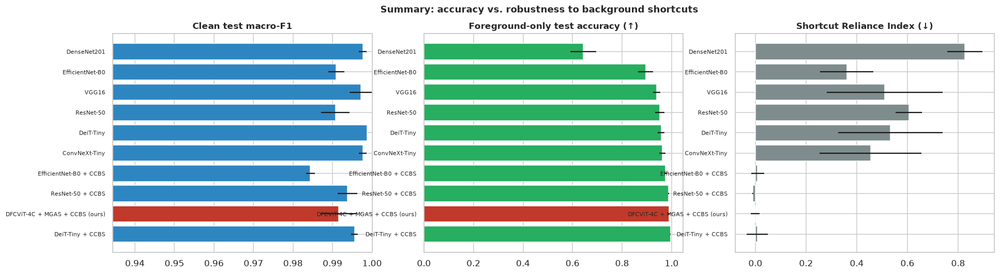

  ↳ figure saved: figures/fig22_final_summary.png (+ .pdf)

Saved files:
  models/DFCViT4C_MGAS_CCBS_final.pt                              12.31 MB
  models/DFCViT4C_MGAS_CCBS_final_torchscript.pt                  12.80 MB
  figures/fig01_class_distribution.pdf                             0.03 MB
  figures/fig01_class_distribution.png                             0.24 MB
  figures/fig02_samples_per_class.pdf                              7.84 MB
  figures/fig02_samples_per_class.png                              9.28 MB
  figures/fig03_colour_and_background_statistics.pdf               0.03 MB
  figures/fig03_colour_and_background_statistics.png               0.15 MB
  figures/fig04_phash_nearest_neighbour.pdf                        0.02 MB
  figures/fig04_phash_nearest_neighbour.png                        0.10 MB
  figures/fig05_near_duplicate_examples.pdf                        3.03 MB
  figures/fig05_near_duplicate_examples.png                        3.41 MB
  figures/fig06_mask_area.p

In [20]:
# ── 20 · Summary ──────────────────────────────────────────────────────────────
print("=" * 88)
print("  FINAL SUMMARY – DFCViT-4C + MGAS + CCBS (4-class dragon fruit)")
print("=" * 88)
print(f"  Images used            : {N}  (after exact + near-duplicate cleaning)")
print(f"  Split (group-aware)    : train {len(SPLIT['train'])} | val {len(SPLIT['val'])} | test {len(SPLIT['test'])}")
print(f"  Mask method            : {MASK_METHOD} | valid masks {VALID.sum()}/{N}")
print(f"  Proposed params        : {PROPOSED[0]['params'] / 1e6:.2f} M")
print("  Best hyper-parameters  : " + ", ".join(f"{k}={v:.3g}" for k, v in BEST_HP.items()))
a = pd.DataFrame([audit(r) for r in PROPOSED])
print("\n  Proposed model on TEST (mean ± std over seeds):")
for k, lab in (("acc", "Accuracy"), ("f1", "Macro-F1"), ("fg_acc", "FG-only accuracy"),
               ("bg_acc", "BG-only accuracy (↓)"), ("SRI", "Shortcut Reliance Index (↓)")):
    print(f"    {lab:<30}: {fmt_ms(a[k])}")
if KFOLD_RESULTS:
    kv = pd.DataFrame([audit(r) for r in KFOLD_RESULTS])
    print(f"\n  5-fold CV accuracy             : {fmt_ms(kv.acc)}")
    print(f"  5-fold CV FG-only accuracy     : {fmt_ms(kv.fg_acc)}")
print("\n  Model comparison (sorted by FG-only accuracy):")
display(cmp_df[["Model", "Params (M)", "Acc", "Macro-F1", "FG-only Acc", "BG-only Acc", "SRI ↓"]].round(4))
if ABL_RESULTS: print("\n  Ablation:"); display(abl_df[["Model", "Acc", "Macro-F1", "FG-only Acc", "BG-only Acc", "SRI ↓"]].round(4))

save_json(dict(n_images=N, split={k: len(v) for k, v in SPLIT.items()}, mask_method=MASK_METHOD, best_hp=BEST_HP,
               proposed=[audit(r) for r in PROPOSED], comparison=cmp_df.to_dict("records"),
               ablation=abl_df.to_dict("records") if ABL_RESULTS else None,
               kfold=[audit(r) for r in KFOLD_RESULTS]), C.WORK_DIR / "summary.json")

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].barh(cmp_df.Model, cmp_df["Macro-F1"], xerr=cmp_df["Macro-F1 std"], color=["#C0392B" if "ours" in m else "#2E86C1" for m in cmp_df.Model])
ax[0].set_xlim(max(0, cmp_df["Macro-F1"].min() - 0.05), 1.0); ax[0].set_title("Clean test macro-F1"); ax[0].tick_params(axis="y", labelsize=7)
ax[1].barh(cmp_df.Model, cmp_df["FG-only Acc"], xerr=cmp_df["FG-only Acc std"], color=["#C0392B" if "ours" in m else "#27AE60" for m in cmp_df.Model])
ax[1].set_title("Foreground-only test accuracy (↑)"); ax[1].tick_params(axis="y", labelsize=7)
ax[2].barh(cmp_df.Model, cmp_df["SRI ↓"], xerr=cmp_df["SRI ↓ std"], color=["#C0392B" if "ours" in m else "#7F8C8D" for m in cmp_df.Model])
ax[2].set_title("Shortcut Reliance Index (↓)"); ax[2].tick_params(axis="y", labelsize=7)
fig.suptitle("Summary: accuracy vs. robustness to background shortcuts", fontweight="bold")
save_fig(fig, "fig22_final_summary")

print("\nSaved files:")
for sub in (MODEL_DIR, FIG_DIR, TAB_DIR):
    for f in sorted(sub.glob("*")):
        print(f"  {str(f.relative_to(C.WORK_DIR)):<60} {f.stat().st_size / 1e6:8.2f} MB")
print("\nNotebook complete ✓")

## 21 · Sanity check: reload the saved `.pt` files and predict test images
Confirms the final model file works exactly as stored (this is also the code to use for deployment).

Loaded DFCViT4C_MGAS_CCBS_final.pt: classes=['Bad', 'Defect', 'Immature', 'Mature'] | stored test metrics: acc=0.9955, f1=0.9962, fg_acc=0.9892, fg_f1=0.9856, bg_acc=0.2612, SRI=0.0150, FSR=0.9938


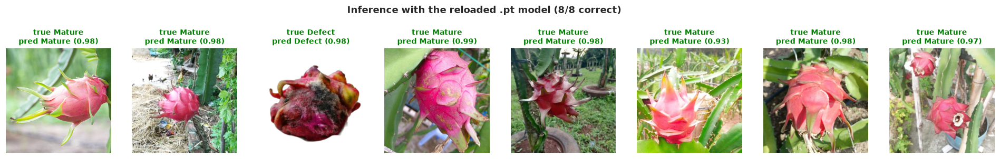

  ↳ figure saved: figures/fig23_reloaded_model_inference.png (+ .pdf)
TorchScript .pt reload OK – max |Δ| vs state-dict model: 1.13e-03


/home/aiub/.venv/lib/python3.14/site-packages/torch/jit/_serialization.py:170: FutureWarning: `torch.jit.load` is not supported in Python 3.14+ and may break. Please switch to `torch.export`.
  warnings.warn(


In [21]:
# ── 21 · Reload & inference ───────────────────────────────────────────────────
ck = torch.load(FINAL_PT, map_location=DEVICE, weights_only=False)
reloaded = DFCViT4C(pretrained=False, **ck["arch_kwargs"]).to(DEVICE).eval()
reloaded.load_state_dict(ck["model_state_dict"], strict=True)
print(f"Loaded {FINAL_PT.name}: classes={ck['classes']} | stored test metrics: "
      + ", ".join(f"{k}={v:.4f}" for k, v in ck["test_metrics"].items()))

def predict_image(path_or_array, model=reloaded):
    img = path_or_array if isinstance(path_or_array, np.ndarray) else load_resize(str(path_or_array))
    x = cv2.resize(img, (ck["img_size"], ck["img_size"]), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    x = torch.from_numpy(((x - np.array(ck["mean"])) / np.array(ck["std"])).transpose(2, 0, 1)).float()[None].to(DEVICE)
    with torch.no_grad():
        p = model(x).float().softmax(1)[0].cpu().numpy()
    return ck["classes"][int(p.argmax())], p

_rng = np.random.default_rng(7)
demo = _rng.choice(SPLIT["test"], 8, replace=False)
fig, axes = plt.subplots(1, 8, figsize=(22, 3.4))
n_ok = 0
for a, j in zip(axes, demo):
    lab, p = predict_image(META.path[j])
    ok = lab == C.CLASSES[LABELS[j]]; n_ok += ok
    a.imshow(IMGS[j]); a.axis("off")
    a.set_title(f"true {C.CLASSES[LABELS[j]]}\npred {lab} ({p.max():.2f})", fontsize=9, color="green" if ok else "red")
fig.suptitle(f"Inference with the reloaded .pt model ({n_ok}/8 correct)", fontweight="bold")
save_fig(fig, "fig23_reloaded_model_inference")

if FINAL_TS.exists():
    ts = torch.jit.load(str(FINAL_TS), map_location=DEVICE).eval()
    xx = torch.randn(4, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE)
    with torch.no_grad():
        print(f"TorchScript .pt reload OK – max |Δ| vs state-dict model: {(ts(xx) - reloaded(xx)).abs().max().item():.2e}")

## 22 · Efficiency — parameters, FLOPs, model size and inference speed (GPU & CPU)
Measured for the proposed model, the MobileNetV2 backbone alone (ablation A1) and every baseline, with **no training** (random weights give the same cost as trained weights).

* **FLOPs** per 224×224 image with `torch.utils.flop_counter` (FLOPs = 2 × multiply-accumulates).
* **GPU**: bf16 autocast, channels-last (same as evaluation) — median latency at batch 1 and throughput at batch 64.
* **CPU**: fp32, batch 1, fixed number of threads — median latency (edge / no-GPU deployment).
* Accuracy columns are taken from the comparison (Section 15) and ablation (Section 16) tables.

Outputs: `tables/tab09_efficiency.csv`, `figures/fig24_efficiency.png`.


  DFCViT-4C + MGAS + CCBS (ours)        3.01 M |   0.62 GFLOPs | GPU   2.59 ms |     1957 img/s | CPU    28.9 ms
  MobileNetV2 (backbone only, A1)       1.93 M |   0.57 GFLOPs | GPU   2.09 ms |     2027 img/s | CPU    21.0 ms
  ResNet-50                            23.52 M |   8.17 GFLOPs | GPU   2.18 ms |     1023 img/s | CPU    62.7 ms
  EfficientNet-B0                       4.01 M |   0.77 GFLOPs | GPU   2.58 ms |     1976 img/s | CPU    22.9 ms
  ConvNeXt-Tiny                        27.82 M |   8.91 GFLOPs | GPU   2.14 ms |      825 img/s | CPU    48.4 ms
  DeiT-Tiny                             5.53 M |   2.15 GFLOPs | GPU   1.63 ms |     4572 img/s | CPU    33.8 ms
  DenseNet201                          18.10 M |   8.58 GFLOPs | GPU   8.74 ms |      521 img/s | CPU   133.1 ms
  VGG16                               134.28 M |  30.93 GFLOPs | GPU   2.57 ms |      858 img/s | CPU    94.9 ms


,Model,Params (M),GFLOPs,Size fp32 (MB),GPU latency b=1 (ms),GPU throughput b=64 (img/s),"CPU latency b=1, 8 thr (ms)",Clean Acc,FG-only Acc,Params vs ours,FLOPs vs ours,CPU time vs ours
0,"MobileNetV2 (backbone only, A1)",1.928,0.567,7.841,2.086,2027.100,21.043,0.998,0.705,0.640,0.915,0.728
1,DFCViT-4C + MGAS + CCBS (ours),3.012,0.619,12.178,2.592,1956.708,28.907,0.993,0.989,1.000,1.000,1.000
2,EfficientNet-B0,4.013,0.769,16.219,2.577,1975.964,22.903,0.994,0.895,1.332,1.242,0.792
3,DeiT-Tiny,5.525,2.149,22.101,1.630,4571.640,33.762,0.999,0.958,1.834,3.470,1.168
4,DenseNet201,18.101,8.579,73.320,8.742,520.765,133.068,0.999,0.643,6.009,13.849,4.603
5,ResNet-50,23.516,8.174,94.278,2.182,1023.115,62.733,0.995,0.953,7.807,13.196,2.170
6,ConvNeXt-Tiny,27.823,8.910,111.293,2.142,825.252,48.409,0.999,0.962,9.236,14.383,1.675
7,VGG16,134.277,30.932,537.108,2.568,858.241,94.901,0.998,0.940,44.576,49.936,3.283


  ↳ table saved: tables/tab09_efficiency.csv


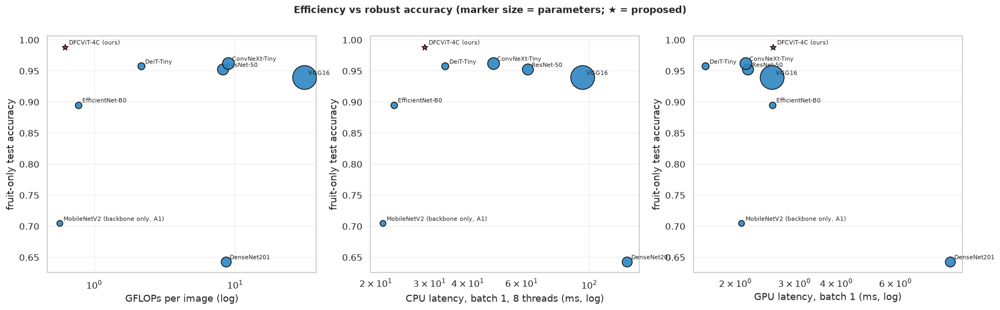

  ↳ figure saved: figures/fig24_efficiency.png (+ .pdf)

Proposed model: 3.01 M params | 0.62 GFLOPs | 12.2 MB | GPU 2.59 ms/img | 1957 img/s | CPU 28.9 ms/img


In [22]:
# ── 22 · Efficiency ───────────────────────────────────────────────────────────
from torch.utils.flop_counter import FlopCounterMode

OURS_NAME = "DFCViT-4C + MGAS + CCBS (ours)"
CPU_THREADS = min(8, os.cpu_count() or 1)                    # fixed thread count → comparable CPU timings
EFF_MODELS = {OURS_NAME: lambda: build_dfcvit(BEST_HP, pretrained=False)}
EFF_MODELS["MobileNetV2 (backbone only, A1)"] = lambda: build_dfcvit(BEST_HP, False, False, False)
for nm, tid in C.BASELINES.items():
    EFF_MODELS[nm] = lambda tid=tid: build_timm(tid)({}, pretrained=False)

def count_flops(m, x):
    with FlopCounterMode(display=False) as fc:
        m(x)
    return fc.get_total_flops()

@torch.no_grad()
def median_ms(m, x, n_warm, n_rep, cuda):
    for _ in range(n_warm): m(x)
    if cuda: torch.cuda.synchronize()
    ts = []
    for _ in range(n_rep):
        t0 = time.perf_counter(); m(x)
        if cuda: torch.cuda.synchronize()
        ts.append(time.perf_counter() - t0)
    return 1000 * float(np.median(ts))

# accuracy columns come from the comparison / ablation tables (Sections 15–16)
_cmp = cmp_df if "cmp_df" in globals() else pd.read_csv(TAB_DIR / "tab04_model_comparison.csv")
_abl = abl_df if "abl_df" in globals() else pd.read_csv(TAB_DIR / "tab05_ablation.csv")
ACC = {r.Model: (r["Acc"], r["FG-only Acc"]) for _, r in _cmp.iterrows()}
_a1 = _abl[_abl.Model.str.startswith("A1")]
if len(_a1): ACC["MobileNetV2 (backbone only, A1)"] = (_a1.iloc[0]["Acc"], _a1.iloc[0]["FG-only Acc"])

eff_rows = []
n_threads0 = torch.get_num_threads()
for nm, build in EFF_MODELS.items():
    m = build().eval()
    params = sum(p.numel() for p in m.parameters())
    size_mb = sum(t.numel() * t.element_size() for t in list(m.parameters()) + list(m.buffers())) / 1e6
    x1 = torch.randn(1, 3, C.IMG_SIZE, C.IMG_SIZE)
    with torch.no_grad():
        flops = count_flops(m, x1)                                     # FLOPs = 2 × multiply-accumulates
    # CPU, fp32, batch 1
    torch.set_num_threads(CPU_THREADS)
    cpu_ms = median_ms(m, x1, 5, 30, cuda=False)
    torch.set_num_threads(n_threads0)
    # GPU, bf16 autocast (same precision as evaluation), batch 1 latency + batch 64 throughput
    gpu_ms = gpu_ips = float("nan")
    if DEVICE.type == "cuda":
        mg = m.to(DEVICE, memory_format=torch.channels_last)
        xg1 = x1.to(DEVICE).contiguous(memory_format=torch.channels_last)
        xg64 = torch.randn(64, 3, C.IMG_SIZE, C.IMG_SIZE, device=DEVICE).contiguous(memory_format=torch.channels_last)
        with autocast_ctx():
            gpu_ms = median_ms(mg, xg1, 30, 200, cuda=True)
            gpu_ips = 64 / (median_ms(mg, xg64, 5, 30, cuda=True) / 1000)
        del mg, xg1, xg64
    acc, fg = ACC.get(nm, (float("nan"), float("nan")))
    eff_rows.append({"Model": nm, "Params (M)": params / 1e6, "GFLOPs": flops / 1e9, "Size fp32 (MB)": size_mb,
                     "GPU latency b=1 (ms)": gpu_ms, "GPU throughput b=64 (img/s)": gpu_ips,
                     f"CPU latency b=1, {CPU_THREADS} thr (ms)": cpu_ms,
                     "Clean Acc": acc, "FG-only Acc": fg})
    print(f"  {nm:<34} {params / 1e6:7.2f} M | {flops / 1e9:6.2f} GFLOPs | GPU {gpu_ms:6.2f} ms | "
          f"{gpu_ips:8.0f} img/s | CPU {cpu_ms:7.1f} ms")
    del m; gc.collect()
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

eff_df = pd.DataFrame(eff_rows).sort_values("Params (M)").reset_index(drop=True)
_o = eff_df[eff_df.Model == OURS_NAME].iloc[0]
cpu_col = f"CPU latency b=1, {CPU_THREADS} thr (ms)"
eff_df["Params vs ours"] = eff_df["Params (M)"] / _o["Params (M)"]
eff_df["FLOPs vs ours"] = eff_df["GFLOPs"] / _o["GFLOPs"]
eff_df["CPU time vs ours"] = eff_df[cpu_col] / _o[cpu_col]
display(eff_df.round(3))
save_table(eff_df.round(4), "tab09_efficiency", "Model efficiency: parameters, FLOPs, size and inference speed")

# ── Figure 24: robust (fruit-only) accuracy vs computational cost ──
fig, ax = plt.subplots(1, 3, figsize=(20, 5.2))
d = eff_df.dropna(subset=["FG-only Acc"])
for a, col, lab in zip(ax, ("GFLOPs", cpu_col, "GPU latency b=1 (ms)"),
                       ("GFLOPs per image (log)", f"CPU latency, batch 1, {CPU_THREADS} threads (ms, log)",
                        "GPU latency, batch 1 (ms, log)")):
    for _, r in d.iterrows():
        ours = r.Model == OURS_NAME
        a.scatter(r[col], r["FG-only Acc"], s=40 + 6 * r["Params (M)"], marker="*" if ours else "o",
                  color="#C0392B" if ours else "#2E86C1", edgecolor="black", zorder=3, alpha=0.9)
        a.annotate(r.Model.replace(" + MGAS + CCBS (ours)", " (ours)"), (r[col], r["FG-only Acc"]), fontsize=7,
                   xytext=(5, 3), textcoords="offset points")
    a.set_xscale("log"); a.set_xlabel(lab); a.set_ylabel("fruit-only test accuracy"); a.grid(alpha=0.3)
fig.suptitle("Efficiency vs robust accuracy (marker size = parameters; ★ = proposed)", fontweight="bold")
save_fig(fig, "fig24_efficiency")

print(f"\nProposed model: {_o['Params (M)']:.2f} M params | {_o['GFLOPs']:.2f} GFLOPs | {_o['Size fp32 (MB)']:.1f} MB | "
      f"GPU {_o['GPU latency b=1 (ms)']:.2f} ms/img | {_o['GPU throughput b=64 (img/s)']:.0f} img/s | CPU {_o[cpu_col]:.1f} ms/img")